# LFP spatial phase coherence vs distance (DIV 12)

Radial spatial phase-coherence analysis (`<cos(phi_i - phi_j)>` vs electrode separation, low-gamma
exp+cosine wavelength fit, activity-quartile split) for the ephaptic-axonal interference model.
Split out of `figure_3_lfp_event_front_compilation.ipynb`; the **event selection is shared** via the
`ephax.metrics.event_selection` backend (`compute_front_null_support` + `front_significant_events`,
`detect_well_bursts`, `peri_anchor_spike_counts`), so both notebooks analyse the identical
front-significant event set.

In [109]:
%matplotlib inline

import json
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from ephax.metrics.lfp import (
    bandpass_downsample,
    dataset_for_well,
    extract_phasors,
    inspect_file,
    load_chunk,
    load_data_store_spikes,
)
from ephax.metrics.event_selection import (
    LFPWavefrontCacheConfig,
    LFPEventFrontBuildConfig,
    WellBurstConfig,
    FrontNullConfig,
    ensure_lfp_wavefront_caches,
    load_all_wavefront_caches,
    detect_well_bursts,
    peri_anchor_spike_counts,
    compute_front_null_support,
    front_significant_events,
)
from ephax.plotting import PAPER_COLORS, apply_paper_style
from ephax.plotting.style import LINE_WIDTHS, FONT_SIZES

apply_paper_style()
plt.rcParams["figure.dpi"] = 150
np.random.seed(0)

In [110]:
DIV = 12
AGGREGATE_WELLS = [0, 1, 2, 3, 4, 5]
EXAMPLE_WELL = 0
CACHE_PROFILE = "confirm"
LFP_SOURCE = "stim_removal_null_lfp"
BAND_LABEL = "30-50 Hz"
FS_DS = 500.0
SAVE_FIGURE = True
BOOTSTRAP_REPS = 10_000
BOOTSTRAP_SEED = 0
NULL_CORRECTION_ENABLED = True
NULL_CORRECTION_FORCE_RECOMPUTE = False
NULL_CORRECTION_REPS = 30
NULL_CORRECTION_SEED = 1
NULL_CORRECTION_TYPES = ["coordinate_shuffle", "arrival_time_shuffle"]
NULL_CORRECTION_MAX_EVENTS_PER_WELL = 25
NULL_FRONT_RADIUS_MM = 0.30
NULL_FRONT_MIN_NEIGHBORS = 8
NULL_FRONT_MAX_RADIUS_MM = 0.45
NULL_FRONT_MAX_NEIGHBORS = 24
NULL_FRONT_MIN_GEOMETRY_RATIO = 0.10
NULL_FRONT_MATCH_MAX_MS = 8.0
NULL_FRONT_MAX_RESIDUAL_MS = 4.0
NULL_FRONT_MIN_ARRIVAL_SPAN_MS = 1.0
NULL_FRONT_MIN_DISTANCE_SPAN_MM = 0.20
NULL_FRONT_MAX_SPEED_MM_PER_S = 500.0
SPEED_PANEL_MODE = "null_corrected"  # "null_corrected" or "all_qc_valid"
LFP_DIAGNOSTIC_PAD_S = 0.05
LFP_FILTER_CONTEXT_PAD_S = 0.25
TRACE_EXAMPLE_CHANNELS = 30
TRACE_EXAMPLE_GAIN = 8.0
SNAPSHOT_HEX_GRIDSIZE = 35
SNAPSHOT_HEX_MIN_VECTOR_COUNT = 3
SNAPSHOT_VECTOR_SCALE_MS = 2.2
SNAPSHOT_VECTOR_MAX_MM = 0.20
PHASE_COH_FREQ_LOW_HZ = 4.0
PHASE_COH_FREQ_HIGH_HZ = 180.0
PHASE_COH_N_BANDS = 28
PHASE_COH_REL_BANDWIDTH = 0.18
PHASE_COH_USE_ALL_CHANNELS = True
PHASE_COH_MAX_CHANNELS = None
TRACE_EXAMPLE_EVENT_IDX = None  # None selects the well-0 event with most valid local fits
MIN_AMP = 0.0
TOP_START = 0
TOP_STOP = 1000
IFR_GRID_HZ = 50.0
SMOOTH_SIGMA_SEC = 0.15
HIGH_ACTIVITY_MAD_SCALE = 3.0
HIGH_ACTIVITY_MIN_DURATION_MS = 30.0
HIGH_ACTIVITY_MAX_GAP_BINS = 0
HIGHRES_BIN_MS = 1.0
HIGHRES_SMOOTH_SIGMA_MS = 3.0
NETWORK_BIN_MS = 10.0
NETWORK_MIN_PARTICIPATION_FRACTION = 0.05
NETWORK_MIN_DURATION_MS = 20.0

STIM_REMOVAL_NULL_LFP_FILE = Path("/Users/danielrebbin/Documents/Academia/UvA/Internship/Wes_Files/Data/LFP/stimRemovalNull") / f"DIV {int(DIV)}" / "data.raw.h5"
WAVE_CACHE_DIR = repo_root / "outputs" / "lfp_waves"
OUTPUT_DIR = repo_root / "outputs" / "figure3_lfp_event_front"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_NOTE = "Cached confirm burst-front screen, 30-50 Hz, 500 Hz"
FIGURE3_PRIMARY_COLOR = PAPER_COLORS["ephaptic_axonal"]
FIGURE3_PRIMARY_LIGHT = "#ead6f6"
FIGURE3_ACCENT_COLOR = PAPER_COLORS["highlight"]
FIGURE3_BURST_COLOR = PAPER_COLORS["burst"]


wavefront_cache_config = LFPWavefrontCacheConfig(
    source=LFP_SOURCE,
    profile=CACHE_PROFILE,
    div=DIV,
    band_low_hz=30.0,
    band_high_hz=50.0,
    fs_hz=FS_DS,
    lambda_min_mm=0.5,
    lambda_max_mm=10.0,
    radial=True,
    interval_mode="burst",
)

cache_paths = ensure_lfp_wavefront_caches(LFPEventFrontBuildConfig(
    raw_file=STIM_REMOVAL_NULL_LFP_FILE,
    cache_dir=WAVE_CACHE_DIR,
    cache=wavefront_cache_config,
    wells=tuple(AGGREGATE_WELLS),
    profile_calibration_events=None if CACHE_PROFILE == "confirm" else 25,
    profile_scoring_events=200 if CACHE_PROFILE == "confirm" else 15,
    min_amp=MIN_AMP,
    top_start=TOP_START,
    top_stop=TOP_STOP,
    ifr_grid_hz=IFR_GRID_HZ,
    smooth_sigma_sec=SMOOTH_SIGMA_SEC,
    high_activity_mad_scale=HIGH_ACTIVITY_MAD_SCALE,
    high_activity_min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
    high_activity_max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
    highres_bin_ms=HIGHRES_BIN_MS,
    highres_smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS,
    network_bin_ms=NETWORK_BIN_MS,
    network_min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
    network_min_duration_ms=NETWORK_MIN_DURATION_MS,
    phase_pad_s=LFP_FILTER_CONTEXT_PAD_S,
    search_pre_ms=20.0,
    search_post_ms=40.0,
    match_max_ms=NULL_FRONT_MATCH_MAX_MS,
    radius_mm=NULL_FRONT_RADIUS_MM,
    min_neighbors=NULL_FRONT_MIN_NEIGHBORS,
    max_radius_mm=NULL_FRONT_MAX_RADIUS_MM,
    max_neighbors=NULL_FRONT_MAX_NEIGHBORS,
    min_geometry_ratio=NULL_FRONT_MIN_GEOMETRY_RATIO,
    max_residual_ms=NULL_FRONT_MAX_RESIDUAL_MS,
    min_arrival_span_ms=NULL_FRONT_MIN_ARRIVAL_SPAN_MS,
    min_distance_span_mm=NULL_FRONT_MIN_DISTANCE_SPAN_MM,
    max_speed_mm_per_s=NULL_FRONT_MAX_SPEED_MM_PER_S,
), build_missing=True)
AGGREGATE_WELLS = sorted(cache_paths)

if int(EXAMPLE_WELL) not in cache_paths:
    EXAMPLE_WELL = int(sorted(cache_paths)[0])
    print(f"EXAMPLE_WELL was unavailable; using well {EXAMPLE_WELL}.")

cache_manifest_df = pd.DataFrame([
    {"well": well, "cache_path": str(path), "cache_name": path.name}
    for well, path in sorted(cache_paths.items())
])
display(cache_manifest_df)
cache_paths


,well,cache_path,cache_name
0,0,/Users/danielrebbin/Documents/GitHub/ephax/out...,wavefront_stim_removal_null_lfp_confirm_well0_...
1,1,/Users/danielrebbin/Documents/GitHub/ephax/out...,wavefront_stim_removal_null_lfp_confirm_well1_...
2,2,/Users/danielrebbin/Documents/GitHub/ephax/out...,wavefront_stim_removal_null_lfp_confirm_well2_...
3,3,/Users/danielrebbin/Documents/GitHub/ephax/out...,wavefront_stim_removal_null_lfp_confirm_well3_...
4,4,/Users/danielrebbin/Documents/GitHub/ephax/out...,wavefront_stim_removal_null_lfp_confirm_well4_...
5,5,/Users/danielrebbin/Documents/GitHub/ephax/out...,wavefront_stim_removal_null_lfp_confirm_well5_...


{0: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wavefront_stim_removal_null_lfp_confirm_well0_DIV12_data0000_burst_30-50Hz_fs500_lambda0.5-10_radial1.h5'),
 1: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wavefront_stim_removal_null_lfp_confirm_well1_DIV12_data0001_burst_30-50Hz_fs500_lambda0.5-10_radial1.h5'),
 2: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wavefront_stim_removal_null_lfp_confirm_well2_DIV12_data0002_burst_30-50Hz_fs500_lambda0.5-10_radial1.h5'),
 3: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wavefront_stim_removal_null_lfp_confirm_well3_DIV12_data0003_burst_30-50Hz_fs500_lambda0.5-10_radial1.h5'),
 4: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wavefront_stim_removal_null_lfp_confirm_well4_DIV12_data0004_burst_30-50Hz_fs500_lambda0.5-10_radial1.h5'),
 5: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wave

In [111]:
# Radial-distance-disaggregated phase-coherence settings (pairwise-separation C(r))
PHASE_COH_DIST_N_BINS = 35        # number of linear electrode-separation bins
PHASE_COH_DIST_MAX_MM = None      # None -> auto from the maximum pairwise distance
PHASE_COH_DIST_MIN_PAIRS = 20     # distance bins with fewer pairs are masked (NaN)

In [112]:
calibration_df, calibration_summary_df, event_df, local_df = load_all_wavefront_caches(cache_paths)

local_df["valid"] = local_df["valid"].astype(bool)
valid_local_df = local_df.loc[local_df["valid"] & np.isfinite(local_df["speed_mm_per_s"])].copy()
event_speed_df = (
    valid_local_df.groupby(["well", "event_idx"], as_index=False)
    .agg(
        median_speed_mm_per_s=("speed_mm_per_s", "median"),
        mean_speed_mm_per_s=("speed_mm_per_s", "mean"),
        n_valid_local_fits=("speed_mm_per_s", "size"),
    )
)
print(f"Loaded {len(event_df)} events, {len(valid_local_df)} QC-valid local fits, {len(event_speed_df)} event medians.")

Loaded 1064 events, 536097 QC-valid local fits, 1064 event medians.


## Shared event selection: null-corrected front-significant events

Same backend call as figure 3 (`compute_front_null_support` + `front_significant_events`), so the
event set is identical by construction (same `local_df`, params and seed).

In [113]:
_front_null_cfg = FrontNullConfig(
    radius_mm=NULL_FRONT_RADIUS_MM, min_neighbors=NULL_FRONT_MIN_NEIGHBORS,
    max_radius_mm=NULL_FRONT_MAX_RADIUS_MM, max_neighbors=NULL_FRONT_MAX_NEIGHBORS,
    min_geometry_ratio=NULL_FRONT_MIN_GEOMETRY_RATIO, match_max_ms=NULL_FRONT_MATCH_MAX_MS,
    max_residual_ms=NULL_FRONT_MAX_RESIDUAL_MS, min_arrival_span_ms=NULL_FRONT_MIN_ARRIVAL_SPAN_MS,
    min_distance_span_mm=NULL_FRONT_MIN_DISTANCE_SPAN_MM, max_speed_mm_per_s=NULL_FRONT_MAX_SPEED_MM_PER_S,
)
front_null_df = compute_front_null_support(
    local_df, event_speed_df,
    null_types=NULL_CORRECTION_TYPES, reps=NULL_CORRECTION_REPS, seed=NULL_CORRECTION_SEED,
    max_events_per_well=NULL_CORRECTION_MAX_EVENTS_PER_WELL, cfg=_front_null_cfg,
    cache_path=OUTPUT_DIR / "tables" / f"spatial_null_support_DIV{int(DIV)}.csv",
    force_recompute=NULL_CORRECTION_FORCE_RECOMPUTE,
)
_corrected = front_significant_events(event_speed_df, front_null_df, support_quantile=0.95)
null_corrected_event_speed_df = _corrected.loc[
    _corrected["front_significant"].astype(bool) & np.isfinite(_corrected["median_speed_mm_per_s"])
].copy()
speed_panel_event_df = null_corrected_event_speed_df
_well_medians = null_corrected_event_speed_df.groupby("well")["median_speed_mm_per_s"].median()
speed_panel_hierarchical_summary = {"median_mm_per_s": float(_well_medians.median())}
print(f"Front-significant events: {len(null_corrected_event_speed_df)} across "
      f"{null_corrected_event_speed_df['well'].nunique()} wells; "
      f"v_eph (hierarchical median) = {speed_panel_hierarchical_summary['median_mm_per_s'] / 1000.0:.3f} mm/ms")

Front-significant events: 115 across 6 wells; v_eph (hierarchical median) = 0.084 mm/ms


In [114]:
WELL_BURST_CFG = WellBurstConfig(
    min_amp=MIN_AMP, top_start=TOP_START, top_stop=TOP_STOP,
    ifr_grid_hz=IFR_GRID_HZ, smooth_sigma_sec=SMOOTH_SIGMA_SEC,
    high_activity_mad_scale=HIGH_ACTIVITY_MAD_SCALE,
    high_activity_min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
    high_activity_max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
    highres_bin_ms=HIGHRES_BIN_MS, highres_smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS,
    network_bin_ms=NETWORK_BIN_MS,
    network_min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
    network_min_duration_ms=NETWORK_MIN_DURATION_MS,
)


def detect_example_well_bursts(well):
    return detect_well_bursts(STIM_REMOVAL_NULL_LFP_FILE, dataset_for_well(well), cfg=WELL_BURST_CFG,
                              cache_dir=OUTPUT_DIR / "burst_cache")

In [115]:
_ex_events = speed_panel_event_df.loc[speed_panel_event_df["well"] == int(EXAMPLE_WELL)]
if _ex_events.empty:
    EXAMPLE_WELL = int(sorted(speed_panel_event_df["well"].unique())[0])
    _ex_events = speed_panel_event_df.loc[speed_panel_event_df["well"] == int(EXAMPLE_WELL)]
_ex = _ex_events.sort_values("n_valid", ascending=False).iloc[0]
_ex_event_idx = int(_ex["event_idx"])
_ex_anchor = float(event_df.loc[
    (event_df["well"].astype(int) == int(EXAMPLE_WELL)) & (event_df["event_idx"].astype(int) == _ex_event_idx),
    "anchor_time_s"].iloc[0])
_ex_bursts, _ex_info = detect_example_well_bursts(int(EXAMPLE_WELL))
_j = int(np.argmin(np.abs(_ex_bursts["anchor_time_s"].to_numpy(float) - _ex_anchor)))
_ex_core = (float(_ex_bursts["start_time_s"].iloc[_j]), float(_ex_bursts["end_time_s"].iloc[_j]))
_rec_stop = _ex_info["raw_shape"][1] / _ex_info["fs_raw"]
example_trace_data = {
    "well": int(EXAMPLE_WELL), "event_idx": _ex_event_idx, "anchor_time_s": _ex_anchor,
    "core_interval_s": _ex_core,
    "display_interval_s": (max(0.0, _ex_core[0] - LFP_DIAGNOSTIC_PAD_S), min(_rec_stop, _ex_core[1] + LFP_DIAGNOSTIC_PAD_S)),
    "filter_interval_s": (max(0.0, _ex_core[0] - LFP_FILTER_CONTEXT_PAD_S), min(_rec_stop, _ex_core[1] + LFP_FILTER_CONTEXT_PAD_S)),
}
print(f"Example event: well {EXAMPLE_WELL}, event {_ex_event_idx}, core "
      f"{_ex_core[0]:.3f}-{_ex_core[1]:.3f}s")

Example event: well 0, event 113, core 366.340-366.400s


## Standalone phase-coherence diagnostic

Two complementary views of the example event's LFP phase field, over a bank of
log-spaced frequency bands:

1. **Global spatial coherence** — the order-parameter magnitude `R(t) = |mean over channels of the unit phasors|`
   per band and time sample, i.e. how phase-aligned the *whole* array is at each instant.
2. **Spatial coherence vs. electrode separation** — the instantaneous phase alignment
   `<cos(phi_i - phi_j)>` averaged over the burst core window and binned by separation distance `||xi - xj||`.
   This is the distance-resolved decomposition of the aggregate order parameter (`R^2` equals the mean of
   `cos(dphi)` over all pairs), so it reads ~0 where the field is spatially incoherent and ~1 only where
   channels are genuinely in phase — revealing the coherence length of gamma vs. lower-frequency bands.
   A time-averaged PLV is **not** used here: for a narrowband pair the phase difference is nearly constant,
   so `|<exp(i dphi)>_t|` is trivially ~1 regardless of true coupling. Distance bins are controlled by
   `PHASE_COH_DIST_*`; the pairwise math reuses the per-band phasors, so it adds negligible runtime.

Phase-coherence heatmap: 1020 channels, 28 log-spaced bands, 366.290-366.450s


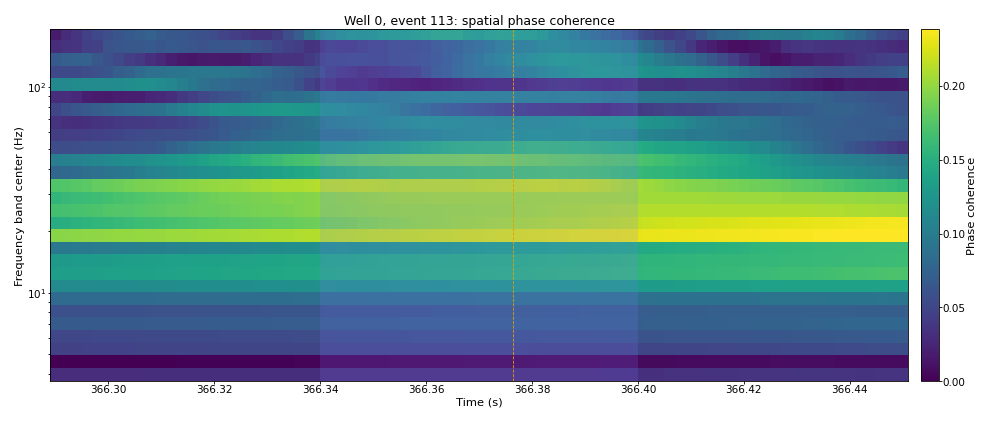

Distance-frequency coherence: 35 separation bins 0-4.11 mm, 28 bands, core window 366.340-366.400s (31 samples)


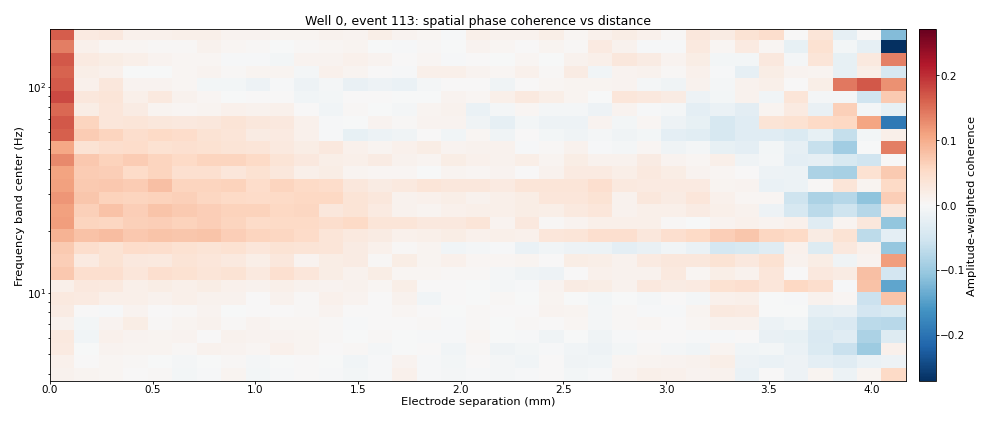

In [116]:
def make_log_frequency_bands(low_hz, high_hz, n_bands, rel_bandwidth, *, fs_ds=500.0):
    centers = np.geomspace(float(low_hz), float(high_hz), int(n_bands))
    nyquist = 0.5 * float(fs_ds)
    bands = []
    for center in centers:
        half_width = 0.5 * float(rel_bandwidth) * center
        band_low = max(0.25, center - half_width)
        band_high = min(0.98 * nyquist, center + half_width)
        if band_high <= band_low:
            continue
        bands.append((float(center), float(band_low), float(band_high)))
    return pd.DataFrame(bands, columns=["center_hz", "low_hz", "high_hz"])


def pairwise_distance_bins(coords_mm, n_bins, max_mm=None):
    """Upper-triangle electrode-pair distances and their linear-bin assignment.

    Returns the row/col index arrays for the upper triangle (i<j), each pair's
    separation in mm, its distance-bin index, per-bin pair counts, and the bin
    edges/centers. Pairs beyond ``max_mm`` (when given explicitly) are dropped.
    """
    coords = np.asarray(coords_mm, dtype=float)
    iu = np.triu_indices(coords.shape[0], 1)
    diff = coords[iu[0]] - coords[iu[1]]
    d = np.sqrt(np.einsum("ij,ij->i", diff, diff))
    hi = float(max_mm) if max_mm is not None else float(d.max())
    in_range = d <= hi
    iu0, iu1, d = iu[0][in_range], iu[1][in_range], d[in_range]
    edges = np.linspace(0.0, hi, int(n_bins) + 1)
    bin_idx = np.clip(np.digitize(d, edges) - 1, 0, int(n_bins) - 1)
    counts = np.bincount(bin_idx, minlength=int(n_bins)).astype(float)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return {
        "iu0": iu0,
        "iu1": iu1,
        "distances_mm": d,
        "bin_idx": bin_idx,
        "counts": counts,
        "edges_mm": edges,
        "centers_mm": centers,
    }


def compute_example_phase_coherence_heatmap(trace, *, use_all_channels=True, max_channels=None):
    well = int(trace["well"])
    dataset = dataset_for_well(well)
    info = inspect_file(STIM_REMOVAL_NULL_LFP_FILE, dataset)
    filter_interval = tuple(float(v) for v in trace["filter_interval_s"])
    display_interval = tuple(float(v) for v in trace["display_interval_s"])
    core_interval = tuple(float(v) for v in trace["core_interval_s"])
    start_frame = int(round(filter_interval[0] * info["fs_raw"]))
    n_frames = max(1, int(round((filter_interval[1] - filter_interval[0]) * info["fs_raw"])))
    raw_full, coords_mm, fs_raw, mapping = load_chunk(STIM_REMOVAL_NULL_LFP_FILE, dataset, start_frame, n_frames)
    channel_ids = np.asarray(mapping["channel"])
    if use_all_channels:
        channel_idx = np.arange(raw_full.shape[1])
    else:
        selected = np.asarray(trace["channels"])
        channel_idx = np.flatnonzero(np.isin(channel_ids, selected))
    if max_channels is not None and channel_idx.size > int(max_channels):
        pick = np.round(np.linspace(0, channel_idx.size - 1, int(max_channels))).astype(int)
        channel_idx = channel_idx[pick]
    if channel_idx.size == 0:
        raise ValueError("No channels available for phase-coherence heatmap")
    raw_selected = raw_full[:, channel_idx]
    coords_sel = np.asarray(coords_mm, dtype=float)[channel_idx]
    dist_bins = pairwise_distance_bins(coords_sel, PHASE_COH_DIST_N_BINS, PHASE_COH_DIST_MAX_MM)
    bands = make_log_frequency_bands(
        PHASE_COH_FREQ_LOW_HZ,
        PHASE_COH_FREQ_HIGH_HZ,
        PHASE_COH_N_BANDS,
        PHASE_COH_REL_BANDWIDTH,
        fs_ds=FS_DS,
    )
    coherence_rows = []
    distance_rows = []
    t_ds_full = None
    display_mask = None
    core_mask = None
    core_n_samples = 0
    for _, row in bands.iterrows():
        band_ds = bandpass_downsample(
            raw_selected,
            fs_raw,
            float(row["low_hz"]),
            float(row["high_hz"]),
            FS_DS,
            max_channels_per_block=128,
        )
        if t_ds_full is None:
            t_ds_full = filter_interval[0] + np.arange(band_ds.shape[0]) / FS_DS
            display_mask = (t_ds_full >= display_interval[0]) & (t_ds_full <= display_interval[1])
            core_mask = (t_ds_full >= core_interval[0]) & (t_ds_full <= core_interval[1])
            if int(core_mask.sum()) < 2:  # burst core too short to average; fall back to display window
                core_mask = display_mask
            core_n_samples = int(core_mask.sum())
        u, _ = extract_phasors(band_ds)
        coherence = np.abs(np.nanmean(u, axis=1))
        coherence_rows.append(coherence[display_mask])
        # Spatial phase coherence vs electrode separation: <cos(phi_i - phi_j)>
        # over the core window. This mirrors the aggregate instantaneous order
        # parameter R(t) = |mean_i u_i(t)| (R^2 = mean over pairs of cos(dphi)),
        # decomposed by distance. Unlike a time-averaged PLV -- |<exp(i dphi)>_t|,
        # which is trivially ~1 for a narrowband pair -- it is 0 when the field is
        # spatially incoherent and ~1 only when channels are genuinely in phase.
        u_core = u[core_mask, :]
        valid = (np.abs(u_core) > 0).astype(np.float32)
        cross = u_core.conj().T @ u_core            # (N, N) complex cross-spectrum
        joint = valid.T @ valid                      # (N, N) jointly-valid sample counts
        cos_dphi = np.real(cross) / np.maximum(joint, 1.0)
        coh_pairs = cos_dphi[dist_bins["iu0"], dist_bins["iu1"]]
        sums = np.bincount(dist_bins["bin_idx"], weights=coh_pairs, minlength=PHASE_COH_DIST_N_BINS)
        counts = dist_bins["counts"]
        c_r = np.full(PHASE_COH_DIST_N_BINS, np.nan)
        np.divide(sums, counts, out=c_r, where=counts > 0)
        c_r[counts < PHASE_COH_DIST_MIN_PAIRS] = np.nan
        distance_rows.append(c_r)
    coherence = np.vstack(coherence_rows)
    distance_coherence = np.vstack(distance_rows)
    return {
        "well": well,
        "event_idx": int(trace["event_idx"]),
        "anchor_time_s": float(trace["anchor_time_s"]),
        "core_interval_s": core_interval,
        "display_interval_s": display_interval,
        "filter_interval_s": filter_interval,
        "time_s": t_ds_full[display_mask],
        "bands": bands,
        "coherence": coherence,
        "distance_coherence": distance_coherence,
        "distance_bin_centers_mm": dist_bins["centers_mm"],
        "distance_bin_pair_counts": dist_bins["counts"],
        "core_window_n_samples": core_n_samples,
        "n_channels": int(channel_idx.size),
    }


def draw_phase_coherence_heatmap(coherence_data, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6.4, 2.8), constrained_layout=True)
    time_s = np.asarray(coherence_data["time_s"], dtype=float)
    bands = coherence_data["bands"]
    centers = bands["center_hz"].to_numpy(float)
    coherence = np.asarray(coherence_data["coherence"], dtype=float)
    vmax = float(np.nanmax(coherence)) if np.any(np.isfinite(coherence)) else 1.0
    vmax = max(vmax, np.finfo(float).eps)
    mesh = ax.pcolormesh(time_s, centers, coherence, shading="auto", cmap="viridis", vmin=0.0, vmax=vmax)
    core = coherence_data["core_interval_s"]
    ax.axvspan(core[0], core[1], color=FIGURE3_PRIMARY_COLOR, alpha=0.16, linewidth=0)
    ax.axvline(coherence_data["anchor_time_s"], color=FIGURE3_ACCENT_COLOR, lw=LINE_WIDTHS["base"], ls="--")
    ax.set_yscale("log")
    ax.set(
        xlabel="Time (s)",
        ylabel="Frequency band center (Hz)",
        title=f"Well {coherence_data['well']}, event {coherence_data['event_idx']}: spatial phase coherence",
    )
    cbar = ax.figure.colorbar(mesh, ax=ax, pad=0.015)
    cbar.set_label("Phase coherence")
    return {"mappable": mesh, "colorbar": cbar}


def draw_distance_frequency_coherence_heatmap(coherence_data, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6.4, 2.8), constrained_layout=True)
    dist_centers = np.asarray(coherence_data["distance_bin_centers_mm"], dtype=float)
    bands = coherence_data["bands"]
    centers = bands["center_hz"].to_numpy(float)
    coherence = np.ma.masked_invalid(np.asarray(coherence_data["distance_coherence"], dtype=float))
    vmax = float(np.abs(coherence).max()) if coherence.count() else 1.0
    vmax = max(vmax, np.finfo(float).eps)
    # signed coherence (<cos dphi> in [-1, 1]); diverging map centred on 0 = incoherent.
    mesh = ax.pcolormesh(dist_centers, centers, coherence, shading="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_yscale("log")
    ax.set(
        xlabel="Electrode separation (mm)",
        ylabel="Frequency band center (Hz)",
        title=f"Well {coherence_data['well']}, event {coherence_data['event_idx']}: spatial phase coherence vs distance",
    )
    cbar = ax.figure.colorbar(mesh, ax=ax, pad=0.015)
    cbar.set_label("Amplitude-weighted coherence")
    return {"mappable": mesh, "colorbar": cbar}


phase_coherence_data = compute_example_phase_coherence_heatmap(
    example_trace_data,
    use_all_channels=PHASE_COH_USE_ALL_CHANNELS,
    max_channels=PHASE_COH_MAX_CHANNELS,
)
print(
    f"Phase-coherence heatmap: {phase_coherence_data['n_channels']} channels, "
    f"{len(phase_coherence_data['bands'])} log-spaced bands, "
    f"{phase_coherence_data['display_interval_s'][0]:.3f}-{phase_coherence_data['display_interval_s'][1]:.3f}s"
)

fig, ax = plt.subplots(figsize=(6.5, 2.7), constrained_layout=True)
draw_phase_coherence_heatmap(phase_coherence_data, ax=ax)
plt.show()

print(
    f"Distance-frequency coherence: {phase_coherence_data['distance_coherence'].shape[1]} separation bins "
    f"0-{phase_coherence_data['distance_bin_centers_mm'][-1]:.2f} mm, "
    f"{len(phase_coherence_data['bands'])} bands, core window "
    f"{phase_coherence_data['core_interval_s'][0]:.3f}-{phase_coherence_data['core_interval_s'][1]:.3f}s "
    f"({phase_coherence_data['core_window_n_samples']} samples)"
)

fig, ax = plt.subplots(figsize=(6.5, 2.7), constrained_layout=True)
draw_distance_frequency_coherence_heatmap(phase_coherence_data, ax=ax)
plt.show()

## Burst-interval-averaged phase-coherence spectrum (all downstream events)

The per-event heatmap above is a single event (the one with most valid QC fits). Here we collapse
the time axis to the **burst interval** and average the spatial phase coherence over the log-spaced
frequency bands for **every valid event that enters the downstream speed panel** (`speed_panel_event_df`).
Each event's coherence(frequency) curve is pooled across events (event-level bootstrap 95% CI); the
30–50 Hz wavefront band is shaded. *Heavy:* one raw-LFP load + 28 band filters per event — set
`COH_SPECTRUM_MAX_EVENTS_PER_WELL` to cap for a quick preview.

In [117]:
# --- Per-event coherence caching -----------------------------------------------------------------
# The coherence-spectrum and distance-map loops below refilter the same per-event LFP on every run
# (~8 min/well and ~15-20 min respectively). These helpers persist each event's result to disk keyed
# by (well, event_idx, core interval) plus a config signature, so reruns only recompute events that
# are new or whose parameters changed. Results are byte-identical to recomputing. Set
# COH_CACHE_FORCE_RECOMPUTE = True to rebuild from scratch.
import pickle

COH_CACHE_DIR = OUTPUT_DIR / "coherence_cache"
COH_CACHE_DIR.mkdir(parents=True, exist_ok=True)
COH_CACHE_FORCE_RECOMPUTE = False

def _load_event_cache(path, signature):
    """Return the cached {key: value} dict when the stored config signature matches, else {}."""
    path = Path(path)
    if COH_CACHE_FORCE_RECOMPUTE or not path.exists():
        return {}
    try:
        blob = pickle.loads(path.read_bytes())
    except Exception:
        return {}
    return dict(blob.get("data", {})) if blob.get("signature") == signature else {}

def _save_event_cache(path, signature, data):
    Path(path).write_bytes(pickle.dumps({"signature": signature, "data": data}))

In [118]:
# --- Coherence setup: bands, event set, core intervals, and the fused per-event compute ---
from scipy.optimize import curve_fit
from scipy.stats import chi2 as _chi2_dist

# Global-order-parameter spectrum settings
COH_SPECTRUM_BOOTSTRAP_REPS = 2000
COH_SPECTRUM_SEED = 0
# Distance-resolved <cos dphi> settings
COHDIST_LOWGAMMA_HZ = (30.0, 50.0)
COHDIST_N_DIST_BINS = 50
COHDIST_MAX_DIST_MM = 3.5
COHDIST_FIT_MAX_DIST_MM = 3.5
COHDIST_FIT_MIN_DIST_MM = 0.1
COHDIST_MIN_PAIRS = 50
COHDIST_BOOTSTRAP_REPS = 200
COHDIST_SEED = 0
COHDIST_MODEL_F_HZ = float(globals().get("IFR_PEAK_HZ", 37.76))
COHDIST_MODEL_VAX_MM_PER_MS = 0.62

coh_bands = make_log_frequency_bands(
    PHASE_COH_FREQ_LOW_HZ, PHASE_COH_FREQ_HIGH_HZ, PHASE_COH_N_BANDS, PHASE_COH_REL_BANDWIDTH, fs_ds=FS_DS,
)
coh_band_centers = coh_bands["center_hz"].to_numpy(float)
cohdist_edges = np.linspace(0.0, COHDIST_MAX_DIST_MM, COHDIST_N_DIST_BINS + 1)
cohdist_centers = 0.5 * (cohdist_edges[:-1] + cohdist_edges[1:])

_coh_burst_cache = {}

def _event_core_interval(well, anchor_time_s):
    """Burst (start, end) for the event, matched to the anchor."""
    if well not in _coh_burst_cache:
        bursts, _ = detect_example_well_bursts(well)
        _coh_burst_cache[well] = bursts
    bursts = _coh_burst_cache[well]
    j = int(np.argmin(np.abs(bursts["anchor_time_s"].to_numpy(float) - float(anchor_time_s))))
    return float(bursts["start_time_s"].iloc[j]), float(bursts["end_time_s"].iloc[j])


def event_phase_coherence(well, core_interval_s, dist_edges, *, min_pairs=COHDIST_MIN_PAIRS):
    """ONE filtering pass -> both the global coherence spectrum AND the amplitude-weighted coherence distance map.

    Filtering matches the paper exactly (per-band bandpass_downsample: filter @ raw rate, then
    downsample), so results are bit-identical to computing the two quantities in separate passes.
    Returns (spectrum (n_bands,), distance_map (n_bands, n_bins), pair_counts (n_bins,)).
    """
    dataset = dataset_for_well(well)
    info = inspect_file(STIM_REMOVAL_NULL_LFP_FILE, dataset)
    rec_stop = info["raw_shape"][1] / info["fs_raw"]
    core0, core1 = float(core_interval_s[0]), float(core_interval_s[1])
    filt0 = max(0.0, core0 - LFP_FILTER_CONTEXT_PAD_S)
    filt1 = min(rec_stop, core1 + LFP_FILTER_CONTEXT_PAD_S)
    start_frame = int(round(filt0 * info["fs_raw"]))
    n_frames = max(1, int(round((filt1 - filt0) * info["fs_raw"])))
    raw, coords_mm, fs_raw, _ = load_chunk(STIM_REMOVAL_NULL_LFP_FILE, dataset, start_frame, n_frames)
    coords_mm = np.asarray(coords_mm, dtype=float)
    n_bins = len(dist_edges) - 1
    iu = np.triu_indices(coords_mm.shape[0], 1)
    d = np.linalg.norm(coords_mm[iu[0]] - coords_mm[iu[1]], axis=1)
    in_range = d <= dist_edges[-1]
    iu0, iu1, d = iu[0][in_range], iu[1][in_range], d[in_range]
    bin_idx = np.clip(np.digitize(d, dist_edges) - 1, 0, n_bins - 1)
    counts = np.bincount(bin_idx, minlength=n_bins).astype(float)
    spec = np.full(len(coh_bands), np.nan)
    coh_map = np.full((len(coh_bands), n_bins), np.nan)
    null_var_map = np.full((len(coh_bands), n_bins), np.nan)   # per-bin phase-rotation null variance = 0.5*Sum|cross|^2 / den^2
    t_ds = None
    core_mask = None
    for bi, row in enumerate(coh_bands.itertuples(index=False)):
        band_ds = bandpass_downsample(raw, fs_raw, float(row.low_hz), float(row.high_hz), FS_DS, max_channels_per_block=128)
        if t_ds is None:
            t_ds = filt0 + np.arange(band_ds.shape[0]) / FS_DS
            core_mask = (t_ds >= core0) & (t_ds <= core1)
            if int(core_mask.sum()) < 2:
                core_mask = np.ones(t_ds.shape, dtype=bool)
        u, amp = extract_phasors(band_ds)
        spec[bi] = float(np.nanmean(np.abs(np.nanmean(u, axis=1))[core_mask]))
        # amplitude-weighted coherence vs distance: aggregate the cross-spectrum and the power over
        # the pairs in each bin, then normalise -> low-power (noisy-phase) channels are down-weighted.
        zc = (u * amp)[core_mask, :]
        cross = zc.conj().T @ zc
        p = np.sum(np.abs(zc) ** 2, axis=0)
        cross_pairs = cross[iu0, iu1]
        num = np.bincount(bin_idx, weights=np.real(cross_pairs), minlength=n_bins)
        den = np.bincount(bin_idx, weights=np.sqrt(p[iu0] * p[iu1]), minlength=n_bins)
        ssq = 0.5 * np.bincount(bin_idx, weights=np.abs(cross_pairs) ** 2, minlength=n_bins)   # phase-rotation null variance numerator
        c_r = np.full(n_bins, np.nan)
        np.divide(num, den, out=c_r, where=den > 0)
        c_r[counts < min_pairs] = np.nan
        coh_map[bi] = c_r
        nv = np.full(n_bins, np.nan)
        np.divide(ssq, den ** 2, out=nv, where=den > 0)
        nv[counts < min_pairs] = np.nan
        null_var_map[bi] = nv
    return spec, coh_map, counts, null_var_map


# downstream (front-significant) events with their anchors
coh_downstream = (
    speed_panel_event_df[["well", "event_idx"]].astype(int).drop_duplicates()
    .merge(event_df[["well", "event_idx", "anchor_time_s"]].astype({"well": int, "event_idx": int}).drop_duplicates(["well", "event_idx"]),
           on=["well", "event_idx"], how="left")
    .dropna(subset=["anchor_time_s"]).sort_values(["well", "anchor_time_s"]).reset_index(drop=True)
)
print(f"downstream event set: {len(coh_downstream)} events across {coh_downstream['well'].nunique()} wells")

downstream event set: 115 events across 6 wells


In [119]:
# --- Fused, parallel per-event compute (bit-identical to the serial two-pass version) ---
# One filtering pass per event (not two), distributed across CPU cores. Results are cached per event.
from joblib import Parallel, delayed

_coh_cache_sig = {
    "kind": "phase_coherence_fused", "div": int(DIV), "file": STIM_REMOVAL_NULL_LFP_FILE.name, "fs_ds": float(FS_DS),
    "flo": PHASE_COH_FREQ_LOW_HZ, "fhi": PHASE_COH_FREQ_HIGH_HZ, "nbands": int(PHASE_COH_N_BANDS),
    "relbw": PHASE_COH_REL_BANDWIDTH, "allch": bool(PHASE_COH_USE_ALL_CHANNELS), "maxch": PHASE_COH_MAX_CHANNELS,
    "pad": LFP_FILTER_CONTEXT_PAD_S, "edges": tuple(round(float(e), 5) for e in cohdist_edges),
    "min_pairs": int(COHDIST_MIN_PAIRS), "coh_weighting": "amplitude", "null": "phase_rotation", "ver": 3,
}
_coh_cache_path = COH_CACHE_DIR / "event_phase_coherence_cache.pkl"
_coh_cache = _load_event_cache(_coh_cache_path, _coh_cache_sig)

# resolve burst core intervals serially (detect_well_bursts is cached per well in _coh_burst_cache)
_tasks = []
for _well in sorted(coh_downstream["well"].unique()):
    for _r in coh_downstream[coh_downstream["well"] == _well].itertuples(index=False):
        try:
            _core = _event_core_interval(int(_well), float(_r.anchor_time_s))
            _tasks.append((int(_well), int(_r.event_idx), (float(_core[0]), float(_core[1]))))
        except Exception as exc:
            print(f"  well {int(_well)} event {int(_r.event_idx)}: core-interval skipped ({exc})")

def _key(well, event_idx, core):
    return (int(well), int(event_idx), round(core[0], 4), round(core[1], 4))

_missing = [(w, e, core) for (w, e, core) in _tasks if _key(w, e, core) not in _coh_cache]
print(f"phase coherence: {len(_tasks)} events, {len(_missing)} to compute, {len(_tasks) - len(_missing)} from cache")
if _missing:
    try:
        _results = Parallel(n_jobs=-1, verbose=5)(
            delayed(event_phase_coherence)(w, core, cohdist_edges) for (w, e, core) in _missing
        )
    except Exception as _exc:
        print(f"parallel compute unavailable ({_exc}); falling back to serial")
        _results = [event_phase_coherence(w, core, cohdist_edges) for (w, e, core) in _missing]
    for (w, e, core), res in zip(_missing, _results):
        _coh_cache[_key(w, e, core)] = res
    _save_event_cache(_coh_cache_path, _coh_cache_sig, _coh_cache)

# assemble aggregate arrays in event order
coh_spectra, coh_meta, cohdist_maps, cohdist_counts, cohdist_meta, cohdist_nullvars = [], [], [], [], [], []
for (w, e, core) in _tasks:
    res = _coh_cache.get(_key(w, e, core))
    if res is None:
        continue
    spec, cmap, counts, nvmap = res
    coh_spectra.append(spec); coh_meta.append((w, e))
    cohdist_maps.append(cmap); cohdist_counts.append(counts); cohdist_meta.append((w, e)); cohdist_nullvars.append(nvmap)
if not coh_spectra:
    raise RuntimeError("No downstream-event coherence was computed.")
coh_matrix = np.vstack(coh_spectra)                       # (n_events, n_bands)
cohdist_maps = np.asarray(cohdist_maps)                   # (n_events, n_bands, n_bins)
cohdist_counts = np.asarray(cohdist_counts)
cohdist_pair_counts = np.nanmean(cohdist_counts, axis=0)
cohdist_nullvar = np.asarray(cohdist_nullvars)   # (n_events, n_bands, n_bins) phase-rotation null variance
cohdist_meta_df = pd.DataFrame(cohdist_meta, columns=["well", "event_idx"])
print(f"aggregated {coh_matrix.shape[0]} events x {coh_matrix.shape[1]} bands; "
      f"distance maps {cohdist_maps.shape}")

phase coherence: 115 events, 115 to compute, 0 from cache


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: 

aggregated 115 events x 28 bands; distance maps (115, 28, 50)


[Parallel(n_jobs=-1)]: Done 115 out of 115 | elapsed:  3.7min finished


In [120]:
# --- Coordinate-shuffle null for the distance ripple (per event, cached) ---
# For each downstream event, keep the per-band analytic signals but permute electrode POSITIONS,
# recompute pairwise distances, and re-bin the (unchanged) pairwise coherences. This destroys the
# coherence-vs-distance link while preserving finite-sample bias, amplitude weighting, temporal phase
# structure and global synchrony -> a FLAT null C(r) at each band's chance level. Aggregated over
# events it calibrates the exp+cos ripple significance in the wavelength cell (a group's ripple is
# real only if its dBIC beats this null). Only the small (n_bands, reps, n_bins) tensor is cached;
# the per-pair phasors are never stored. Filtering matches event_phase_coherence exactly.
COHDIST_NULL_REPS = 100
COHDIST_NULL_ALPHA = 0.05
COHDIST_NULL_SEED = 0

def event_coordshuffle_null(well, core_interval_s, dist_edges, reps, seed, *, min_pairs=COHDIST_MIN_PAIRS):
    """R coordinate-shuffle null C(r) per band for one event -> (n_bands, reps, n_bins).

    Same filtering/amplitude weighting as event_phase_coherence; only the electrode POSITIONS are
    permuted, so the pairwise coherences are unchanged and only their distance labels are reshuffled.
    All bands are re-binned in one bincount per rep (flat band*bin index); the shuffle preserves the
    pair-count histogram, so the observed counts are reused for masking (no per-rep count recompute).
    """
    dataset = dataset_for_well(well)
    info = inspect_file(STIM_REMOVAL_NULL_LFP_FILE, dataset)
    rec_stop = info["raw_shape"][1] / info["fs_raw"]
    core0, core1 = float(core_interval_s[0]), float(core_interval_s[1])
    filt0 = max(0.0, core0 - LFP_FILTER_CONTEXT_PAD_S)
    filt1 = min(rec_stop, core1 + LFP_FILTER_CONTEXT_PAD_S)
    start_frame = int(round(filt0 * info["fs_raw"]))
    n_frames = max(1, int(round((filt1 - filt0) * info["fs_raw"])))
    raw, coords_mm, fs_raw, _ = load_chunk(STIM_REMOVAL_NULL_LFP_FILE, dataset, start_frame, n_frames)
    coords_mm = np.asarray(coords_mm, dtype=float); N = coords_mm.shape[0]
    n_bins = len(dist_edges) - 1; nbands = len(coh_bands)
    iu = np.triu_indices(N, 1)
    d = np.linalg.norm(coords_mm[iu[0]] - coords_mm[iu[1]], axis=1)
    in_range = d <= dist_edges[-1]; iu0, iu1, d = iu[0][in_range], iu[1][in_range], d[in_range]
    obs_bins = np.clip(np.digitize(d, dist_edges) - 1, 0, n_bins - 1)
    mask = np.bincount(obs_bins, minlength=n_bins) < min_pairs
    num = np.empty((nbands, iu0.size), np.float32); den = np.empty((nbands, iu0.size), np.float32)
    t_ds = core_mask = None
    for bi, row in enumerate(coh_bands.itertuples(index=False)):
        band_ds = bandpass_downsample(raw, fs_raw, float(row.low_hz), float(row.high_hz), FS_DS, max_channels_per_block=128)
        if t_ds is None:
            t_ds = filt0 + np.arange(band_ds.shape[0]) / FS_DS
            core_mask = (t_ds >= core0) & (t_ds <= core1)
            if int(core_mask.sum()) < 2:
                core_mask = np.ones(t_ds.shape, dtype=bool)
        u, amp = extract_phasors(band_ds)
        zc = (u * amp)[core_mask, :]
        cross = zc.conj().T @ zc; p = np.sum(np.abs(zc) ** 2, axis=0)
        num[bi] = np.real(cross)[iu0, iu1]; den[bi] = np.sqrt(p[iu0] * p[iu1])
    num_r, den_r = num.ravel(), den.ravel(); band_off = (np.arange(nbands) * n_bins)[:, None]
    def _binned(bins):
        flat = (band_off + bins[None, :]).ravel()
        nn = np.bincount(flat, num_r, minlength=nbands * n_bins).reshape(nbands, n_bins)
        dd = np.bincount(flat, den_r, minlength=nbands * n_bins).reshape(nbands, n_bins)
        c = np.full((nbands, n_bins), np.nan); np.divide(nn, dd, out=c, where=dd > 0); c[:, mask] = np.nan
        return c
    rng = np.random.default_rng(seed); null = np.empty((nbands, reps, n_bins), np.float32)
    for r in range(reps):
        pi = rng.permutation(N)
        nb = np.clip(np.digitize(np.linalg.norm(coords_mm[pi[iu0]] - coords_mm[pi[iu1]], axis=1), dist_edges) - 1, 0, n_bins - 1)
        null[:, r, :] = _binned(nb)
    return null

_null_cache_sig = {**_coh_cache_sig, "kind": "coordshuffle_null", "reps": int(COHDIST_NULL_REPS), "seed": int(COHDIST_NULL_SEED)}
_null_cache_path = COH_CACHE_DIR / "event_coordshuffle_null_cache.pkl"
_null_cache = _load_event_cache(_null_cache_path, _null_cache_sig)
_null_missing = [(w, e, core) for (w, e, core) in _tasks if _key(w, e, core) not in _null_cache]
print(f"coordinate-shuffle null: {len(_tasks)} events, {len(_null_missing)} to compute, {len(_tasks) - len(_null_missing)} from cache")
if _null_missing:
    try:
        _null_res = Parallel(n_jobs=-1, verbose=5)(
            delayed(event_coordshuffle_null)(w, core, cohdist_edges, COHDIST_NULL_REPS, COHDIST_NULL_SEED + i)
            for i, (w, e, core) in enumerate(_null_missing))
    except Exception as _exc:
        print(f"parallel null unavailable ({_exc}); falling back to serial")
        _null_res = [event_coordshuffle_null(w, core, cohdist_edges, COHDIST_NULL_REPS, COHDIST_NULL_SEED + i)
                     for i, (w, e, core) in enumerate(_null_missing)]
    for (w, e, core), res in zip(_null_missing, _null_res):
        _null_cache[_key(w, e, core)] = res
    _save_event_cache(_null_cache_path, _null_cache_sig, _null_cache)

# aggregate per-event null tensors over the same event set as cohdist_maps
_null_stack = [_null_cache[_key(w, e, core)] for (w, e, core) in _tasks if _key(w, e, core) in _null_cache]
cohdist_null_agg = np.nanmean(np.stack(_null_stack), axis=0)   # (n_bands, reps, n_bins)
print(f"coordinate-shuffle null aggregated over {len(_null_stack)} events: {cohdist_null_agg.shape} (bands, reps, bins)")


coordinate-shuffle null: 115 events, 115 to compute, 0 from cache


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   40.1s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed: 12.7min
[Parallel(n_jobs=-1)]: Done 115 out of 115 | elapsed: 20.4min finished


coordinate-shuffle null aggregated over 115 events: (28, 100, 50) (bands, reps, bins)


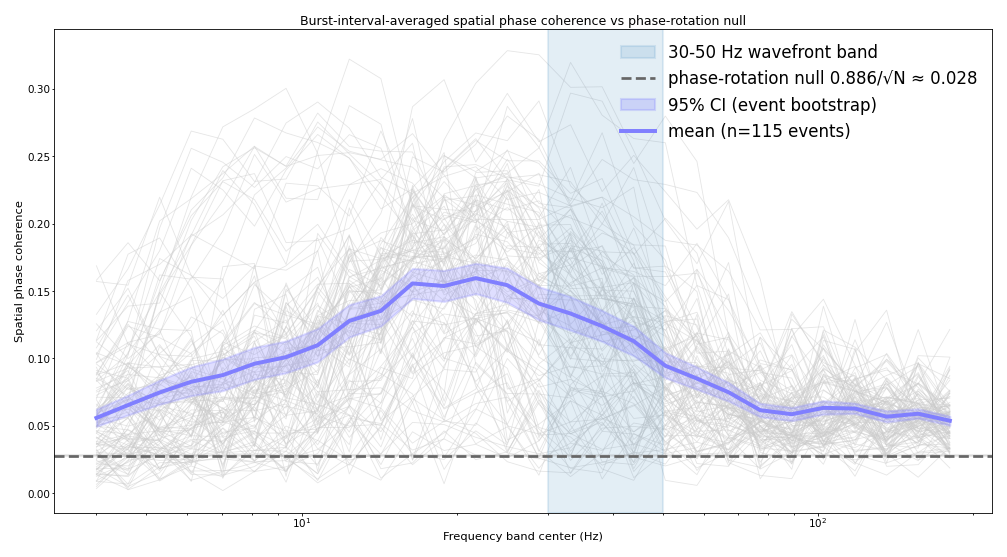

phase-rotation null (order-parameter floor) = 0.0278 (median N ≈ 1015); 28/28 bands above the floor.


In [121]:
# --- Global spatial-coherence spectrum: event bootstrap + phase-rotation null + figure ---
_rng = np.random.default_rng(COH_SPECTRUM_SEED)
coh_mean = np.nanmean(coh_matrix, axis=0)
_boot = np.empty((int(COH_SPECTRUM_BOOTSTRAP_REPS), coh_matrix.shape[1]))
for b in range(int(COH_SPECTRUM_BOOTSTRAP_REPS)):
    _boot[b] = np.nanmean(coh_matrix[_rng.integers(0, coh_matrix.shape[0], coh_matrix.shape[0])], axis=0)
coh_ci_lo = np.nanpercentile(_boot, 2.5, axis=0)
coh_ci_hi = np.nanpercentile(_boot, 97.5, axis=0)

# Phase-rotation null level: rotating every channel by a random constant phase destroys inter-channel
# alignment; for the unit-phasor order parameter this leaves E[R] = 0.886/sqrt(N), a FREQUENCY-INDEPENDENT
# chance floor (data-independent -- confirmed by direct simulation). N per event comes from the pairwise
# counts, so no refiltering is needed. NOTE: this floor treats channels as independent, so it removes
# finite-size sampling noise but NOT volume conduction (for the VC-excluded, distance-resolved phase-
# rotation null see lfp_phase_coherence_diagnostics_div12.ipynb).
_Ns = np.array([max(2, int(round((1 + np.sqrt(1 + 8 * cohdist_counts[i].sum())) / 2))) for i in range(cohdist_counts.shape[0])])
coh_null_level = float(np.mean(0.8862 / np.sqrt(_Ns)))
_Tc = int(np.median([max(2, int(round((c[1] - c[0]) * FS_DS))) for (_w, _e, c) in _tasks]))
_pr_rng = np.random.default_rng(COH_SPECTRUM_SEED + 7); _sim = np.empty(500)
for _k in range(_sim.size):
    _sim[_k] = np.mean(np.abs(np.mean(np.exp(1j * _pr_rng.uniform(0, 2 * np.pi, (_Tc, int(np.median(_Ns))))), axis=1)))
_pr_sd = float(_sim.std() / np.sqrt(coh_matrix.shape[0]))          # aggregate (n-event mean) sampling spread
coh_null_lo, coh_null_hi = coh_null_level - 1.96 * _pr_sd, coh_null_level + 1.96 * _pr_sd

coh_spectrum_df = pd.DataFrame({
    "center_hz": coh_band_centers, "coherence_mean": coh_mean,
    "coherence_ci_low": coh_ci_lo, "coherence_ci_high": coh_ci_hi,
    "phase_rotation_null": coh_null_level,
    "above_null": coh_mean > coh_null_hi,
    "n_events": int(coh_matrix.shape[0]), "n_wells": int(len(set(m[0] for m in coh_meta))),
})
coh_spectrum_df.to_csv(OUTPUT_DIR / "burst_coherence_spectrum_by_frequency.csv", index=False)

fig, ax = plt.subplots(figsize=(6.6, 3.6), constrained_layout=True)
for spec in coh_matrix:
    ax.plot(coh_band_centers, spec, color="0.8", lw=0.4, alpha=0.5, zorder=0)
ax.axvspan(30.0, 50.0, color=FIGURE3_BURST_COLOR, alpha=0.12, zorder=0, label="30-50 Hz wavefront band")
ax.axhspan(coh_null_lo, coh_null_hi, color="0.55", alpha=0.18, zorder=1)
ax.axhline(coh_null_level, color="0.4", lw=1.3, ls="--", zorder=1,
           label=f"phase-rotation null 0.886/\u221aN \u2248 {coh_null_level:.3f}")
ax.fill_between(coh_band_centers, coh_ci_lo, coh_ci_hi, color=FIGURE3_PRIMARY_COLOR, alpha=0.25, label="95% CI (event bootstrap)")
ax.plot(coh_band_centers, coh_mean, color=FIGURE3_PRIMARY_COLOR, lw=1.9, label=f"mean (n={coh_matrix.shape[0]} events)")
ax.set_xscale("log")
ax.set_xlabel("Frequency band center (Hz)")
ax.set_ylabel("Spatial phase coherence")
ax.set_title("Burst-interval-averaged spatial phase coherence vs phase-rotation null")
ax.legend(frameon=False, fontsize=8)
fig.savefig(OUTPUT_DIR / "burst_coherence_spectrum.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"phase-rotation null (order-parameter floor) = {coh_null_level:.4f} (median N \u2248 {int(np.median(_Ns))}); "
      f"{int(np.sum(coh_mean > coh_null_hi))}/{coh_mean.size} bands above the floor.")


### VC-free coherence spectrum vs phase-rotation null
Distance-resolved coherence over 0.1–4 mm (volume conduction excluded) per band, tested against the analytic phase-rotation null (level 0, band-specific width). The VC-excluded, band-specific companion to the order-parameter floor above.

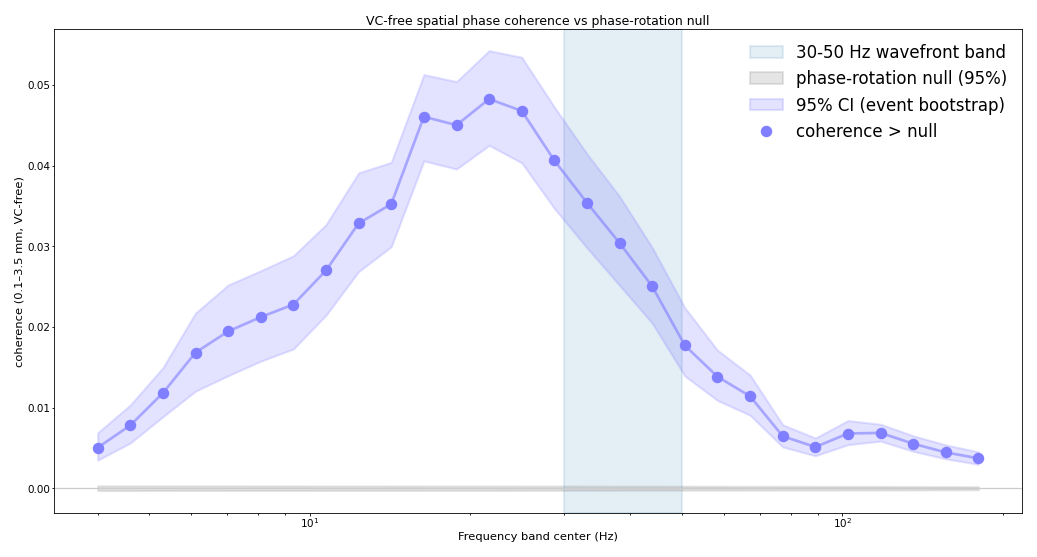

VC-free coherence spectrum (>0.1 mm): 28/28 bands clear the phase-rotation null; peak 0.048 at 22 Hz.


In [122]:
# --- VC-free coherence spectrum vs analytic phase-rotation null ---
# Distance-resolved amplitude-weighted coherence averaged over [COHDIST_FIT_MIN_DIST_MM, COHDIST_FIT_MAX_DIST_MM]
# per band -- volume conduction (confined to < the min distance) is EXCLUDED, so this is genuine network
# coherence. Null: rotating each channel by a random phase leaves every |z| fixed and only spins each pair's
# cross-spectrum, so Re<z_i z_j*> -> mean 0 with per-bin variance 0.5*Sum|cross|^2/den^2 (cohdist_nullvar,
# folded into the cached compute). That null is ANALYTIC (no reps; matches Monte-Carlo to ~1%). Bands whose
# coherence clears the null band carry genuine phase alignment. This is the VC-excluded, band-specific
# companion to the order-parameter finite-N floor above.
_vcm = (cohdist_centers >= COHDIST_FIT_MIN_DIST_MM) & (cohdist_centers <= COHDIST_FIT_MAX_DIST_MM)
_ev_spec = np.nanmean(cohdist_maps[:, :, _vcm], axis=2)                      # (n_events, n_bands)
vcfree_spec = np.nanmean(_ev_spec, axis=0)
_vc_rng = np.random.default_rng(COH_SPECTRUM_SEED)
_vc_boot = np.array([np.nanmean(_ev_spec[_vc_rng.integers(0, _ev_spec.shape[0], _ev_spec.shape[0])], axis=0)
                     for _ in range(int(COH_SPECTRUM_BOOTSTRAP_REPS))])
vcfree_ci_lo, vcfree_ci_hi = np.nanpercentile(_vc_boot, [2.5, 97.5], axis=0)
# analytic phase-rotation null std of the fit-range-mean coherence, per band
_n_ev = cohdist_maps.shape[0]; _K = int(_vcm.sum())
_agg_var = np.nansum(cohdist_nullvar[:, :, _vcm], axis=0) / _n_ev ** 2       # (n_bands, K) aggregate null var per bin
vcfree_null_std = np.sqrt(np.nansum(_agg_var, axis=1)) / _K                  # (n_bands,)
vcfree_signal = vcfree_spec > 1.96 * vcfree_null_std

vcfree_spectrum_df = pd.DataFrame({"center_hz": coh_band_centers, "coherence_vcfree": vcfree_spec,
    "ci_low": vcfree_ci_lo, "ci_high": vcfree_ci_hi, "phase_rotation_null_std": vcfree_null_std,
    "above_null": vcfree_signal, "n_events": int(_n_ev)})
vcfree_spectrum_df.to_csv(OUTPUT_DIR / "vcfree_coherence_spectrum_by_frequency.csv", index=False)

fig, ax = plt.subplots(figsize=(6.8, 3.6), constrained_layout=True)
ax.axvspan(30.0, 50.0, color=FIGURE3_BURST_COLOR, alpha=0.12, zorder=0, label="30-50 Hz wavefront band")
ax.fill_between(coh_band_centers, -1.96 * vcfree_null_std, 1.96 * vcfree_null_std, color="0.55", alpha=0.22, zorder=1, label="phase-rotation null (95%)")
ax.fill_between(coh_band_centers, vcfree_ci_lo, vcfree_ci_hi, color=FIGURE3_PRIMARY_COLOR, alpha=0.22, label="95% CI (event bootstrap)")
ax.plot(coh_band_centers[~vcfree_signal], vcfree_spec[~vcfree_signal], "o", color="0.6", ms=4, zorder=3)
ax.plot(coh_band_centers[vcfree_signal], vcfree_spec[vcfree_signal], "o", color=FIGURE3_PRIMARY_COLOR, ms=4.5, zorder=3, label="coherence > null")
ax.plot(coh_band_centers, vcfree_spec, color=FIGURE3_PRIMARY_COLOR, lw=1.3, alpha=0.6, zorder=2)
ax.axhline(0, color="0.8", lw=0.6)
ax.set_xscale("log"); ax.set_xlabel("Frequency band center (Hz)")
ax.set_ylabel(f"coherence ({COHDIST_FIT_MIN_DIST_MM:g}\u2013{COHDIST_FIT_MAX_DIST_MM:g} mm, VC-free)")
ax.set_title("VC-free spatial phase coherence vs phase-rotation null")
ax.legend(frameon=False, fontsize=8)
fig.savefig(OUTPUT_DIR / "vcfree_coherence_spectrum.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"VC-free coherence spectrum (>{COHDIST_FIT_MIN_DIST_MM:g} mm): {int(vcfree_signal.sum())}/{vcfree_signal.size} bands "
      f"clear the phase-rotation null; peak {np.nanmax(vcfree_spec):.3f} at {coh_band_centers[int(np.nanargmax(vcfree_spec))]:.0f} Hz.")


## Event-aggregated spatial phase coherence vs distance

Pools the corrected spatial coherence `<cos(phi_i - phi_j)>` across the front-significant events
(`coh_downstream`), resolved by frequency band and electrode separation. The aggregate low-gamma
`C(r)` is fitted with an exponential-only vs exponential+cosine model to quantify the interference
wavelength predicted by the ephaptic-axonal model, `lambda = 1 / [ f (1/v_eph - 1/v_ax) ]`. Uncertainty
is a percentile bootstrap over events; the fit is restricted to the well-sampled separation range.

n_events=115, low-gamma 30-50 Hz
fitted wavelength = 2.94 mm (95% CI 2.79-3.07); model prediction = 2.56 mm
RSS reduction (exp -> exp+cos) = 56.0%; LRT chi2=40.3 p=1.80e-09; dBIC=-32.5


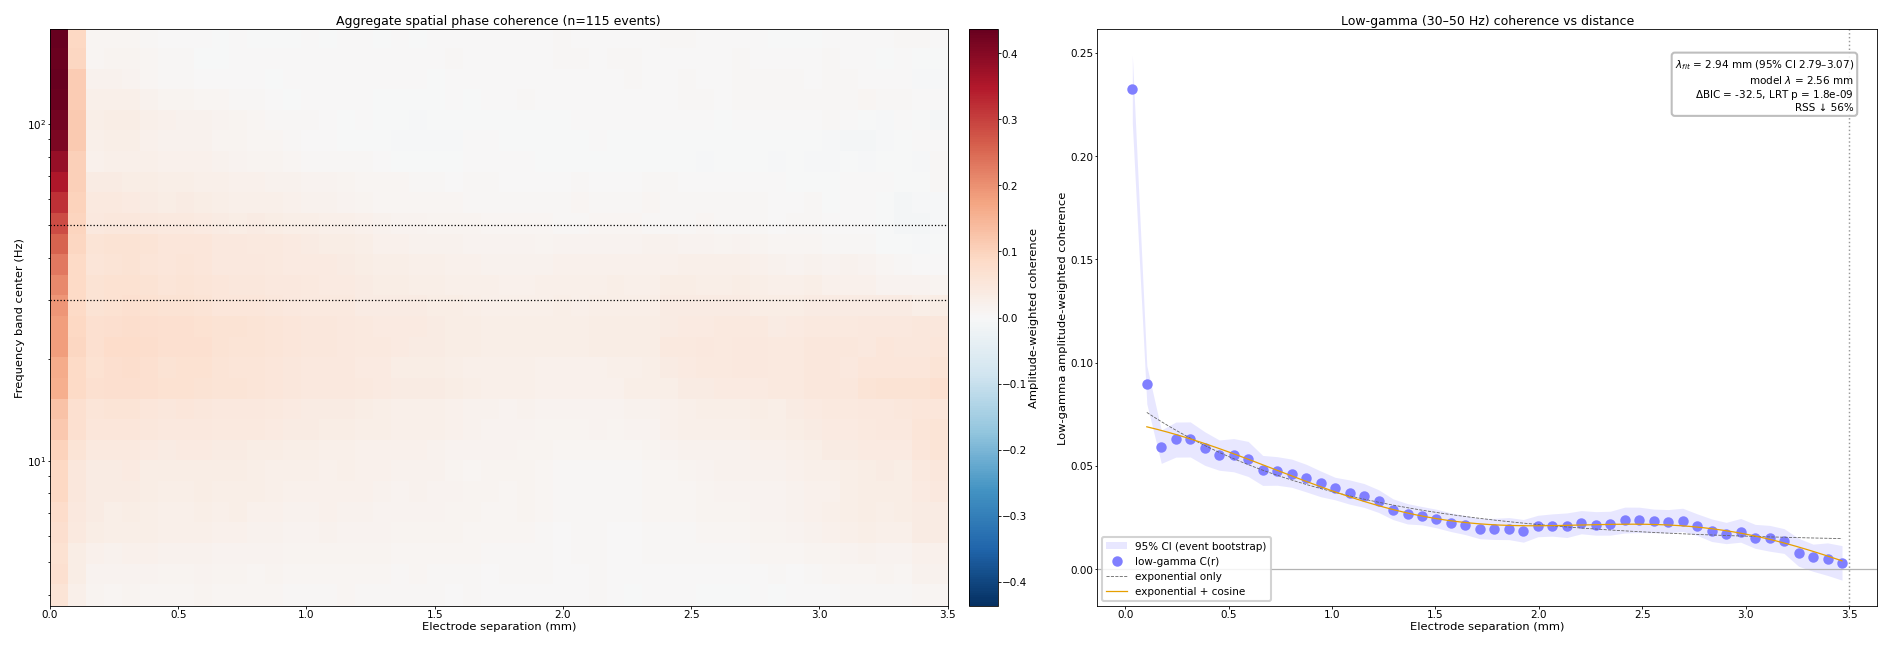

In [123]:
# --- Aggregate coherence-vs-distance: bootstrap CIs + exponential vs exponential+cosine model fit ---

def _coh_exp_model(r, a, lam, b):
    return a * np.exp(-r / lam) + b

def _coh_expcos_model(r, a, lam, b, c, wavelength):
    return a * np.exp(-r / lam) + b + c * np.cos(2.0 * np.pi * r / wavelength)

def _fit_coh_models(r, y, weights):
    sigma = 1.0 / np.sqrt(np.maximum(weights, 1e-9))
    p_exp, _ = curve_fit(_coh_exp_model, r, y, p0=[max(y.max() - y.min(), 1e-3), 1.0, float(np.median(y))],
                         sigma=sigma, maxfev=40000, bounds=([0.0, 0.05, -1.0], [3.0, 20.0, 1.0]))
    p_full, _ = curve_fit(_coh_expcos_model, r, y, p0=[*p_exp, 0.05, 2.3],
                          sigma=sigma, maxfev=80000,
                          bounds=([0.0, 0.05, -1.0, 0.0, 1.0], [3.0, 20.0, 1.0, 1.0, 4.0]))
    rss_exp = float(np.sum(weights * (y - _coh_exp_model(r, *p_exp)) ** 2))
    rss_full = float(np.sum(weights * (y - _coh_expcos_model(r, *p_full)) ** 2))
    return p_exp, p_full, rss_exp, rss_full

# --- low-gamma C(r): pool across events, bootstrap over events ---
lowgamma_mask = (coh_band_centers >= COHDIST_LOWGAMMA_HZ[0]) & (coh_band_centers <= COHDIST_LOWGAMMA_HZ[1])
event_lowgamma_cr = np.nanmean(cohdist_maps[:, lowgamma_mask, :], axis=1)   # (n_events, n_bins)
pooled_cr = np.nanmean(event_lowgamma_cr, axis=0)

fit_mask = np.isfinite(pooled_cr) & (cohdist_centers <= COHDIST_FIT_MAX_DIST_MM) & (cohdist_centers >= COHDIST_FIT_MIN_DIST_MM)
r_fit = cohdist_centers[fit_mask]
w_fit = cohdist_pair_counts[fit_mask]

rng = np.random.default_rng(COHDIST_SEED)
n_events = event_lowgamma_cr.shape[0]
boot_cr = np.full((COHDIST_BOOTSTRAP_REPS, cohdist_centers.size), np.nan)
boot_wavelength = np.full(COHDIST_BOOTSTRAP_REPS, np.nan)
for bi in range(COHDIST_BOOTSTRAP_REPS):
    idx = rng.integers(0, n_events, n_events)
    yb = np.nanmean(event_lowgamma_cr[idx], axis=0)
    boot_cr[bi] = yb
    m = np.isfinite(yb) & (cohdist_centers <= COHDIST_FIT_MAX_DIST_MM) & (cohdist_centers >= COHDIST_FIT_MIN_DIST_MM)
    if m.sum() >= 6:
        try:
            _, pf, _, _ = _fit_coh_models(cohdist_centers[m], yb[m], cohdist_pair_counts[m])
            boot_wavelength[bi] = pf[4]
        except Exception:
            pass
cr_ci_lo, cr_ci_hi = np.nanpercentile(boot_cr, [2.5, 97.5], axis=0)

p_exp, p_full, rss_exp, rss_full = _fit_coh_models(r_fit, pooled_cr[fit_mask], w_fit)
n_fit = r_fit.size
chi2_stat = n_fit * np.log(rss_exp / rss_full)
lrt_p = float(_chi2_dist.sf(chi2_stat, 2))         # 2 extra params (c, wavelength)
delta_bic = n_fit * np.log(rss_full / rss_exp) + 2.0 * np.log(n_fit)   # BIC_full - BIC_exp
fit_wavelength = float(p_full[4])
wl_lo, wl_hi = np.nanpercentile(boot_wavelength, [2.5, 97.5])
rss_reduction = 100.0 * (1.0 - rss_full / rss_exp)

try:
    # lambda = 1 / [ f * (1/v_eph - 1/v_ax) ]; keep all speeds in mm/s with f in Hz.
    veph_mm_per_s = float(speed_panel_hierarchical_summary["median_mm_per_s"])
    vax_mm_per_s = COHDIST_MODEL_VAX_MM_PER_MS * 1000.0
    predicted_wavelength = 1.0 / (COHDIST_MODEL_F_HZ * (1.0 / veph_mm_per_s - 1.0 / vax_mm_per_s))
except Exception:
    predicted_wavelength = np.nan

print(f"n_events={n_events}, low-gamma {COHDIST_LOWGAMMA_HZ[0]:g}-{COHDIST_LOWGAMMA_HZ[1]:g} Hz")
print(f"fitted wavelength = {fit_wavelength:.2f} mm (95% CI {wl_lo:.2f}-{wl_hi:.2f}); model prediction = {predicted_wavelength:.2f} mm")
print(f"RSS reduction (exp -> exp+cos) = {rss_reduction:.1f}%; LRT chi2={chi2_stat:.1f} p={lrt_p:.2e}; dBIC={delta_bic:.1f}")

# --- figure: aggregate heatmap + low-gamma C(r) with model fits ---
fig, (ax_h, ax_l) = plt.subplots(1, 2, figsize=(12.5, 4.2), constrained_layout=True, gridspec_kw={"width_ratios": [1.15, 1.0]})

agg_map = np.ma.masked_invalid(np.nanmean(cohdist_maps, axis=0))
vmax = float(np.abs(agg_map).max()) if agg_map.count() else 1.0
vmax = max(vmax, np.finfo(float).eps)
mesh = ax_h.pcolormesh(cohdist_centers, coh_band_centers, agg_map, shading="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
for edge in (COHDIST_LOWGAMMA_HZ[0], COHDIST_LOWGAMMA_HZ[1]):
    ax_h.axhline(edge, color="k", lw=0.6, ls=":")
ax_h.set_yscale("log")
ax_h.set(xlabel="Electrode separation (mm)", ylabel="Frequency band center (Hz)",
         title=f"Aggregate spatial phase coherence (n={n_events} events)")
cbar = fig.colorbar(mesh, ax=ax_h, pad=0.015)
cbar.set_label("Amplitude-weighted coherence")

ax_l.fill_between(cohdist_centers, cr_ci_lo, cr_ci_hi, color=FIGURE3_PRIMARY_COLOR, alpha=0.18, linewidth=0, label="95% CI (event bootstrap)")
ax_l.plot(cohdist_centers, pooled_cr, "o", color=FIGURE3_PRIMARY_COLOR, ms=4, label="low-gamma C(r)")
r_dense = np.linspace(r_fit.min(), r_fit.max(), 200)
ax_l.plot(r_dense, _coh_exp_model(r_dense, *p_exp), ls="--", color="0.4", lw=LINE_WIDTHS["base"], label="exponential only")
ax_l.plot(r_dense, _coh_expcos_model(r_dense, *p_full), ls="-", color=FIGURE3_ACCENT_COLOR, lw=LINE_WIDTHS["emphasis"], label="exponential + cosine")
ax_l.axvline(COHDIST_FIT_MAX_DIST_MM, color="0.6", lw=0.7, ls=":")
ax_l.axhline(0.0, color="0.7", lw=0.6)
ann = (f"$\\lambda_{{fit}}$ = {fit_wavelength:.2f} mm (95% CI {wl_lo:.2f}–{wl_hi:.2f})\n"
       f"model $\\lambda$ = {predicted_wavelength:.2f} mm\n"
       f"$\\Delta$BIC = {delta_bic:.1f}, LRT p = {lrt_p:.1e}\nRSS ↓ {rss_reduction:.0f}%")
ax_l.text(0.97, 0.95, ann, transform=ax_l.transAxes, ha="right", va="top", fontsize=FONT_SIZES.get("small", 8),
          bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.85))
ax_l.set(xlabel="Electrode separation (mm)",
         ylabel="Low-gamma amplitude-weighted coherence",
         title=f"Low-gamma ({COHDIST_LOWGAMMA_HZ[0]:g}–{COHDIST_LOWGAMMA_HZ[1]:g} Hz) coherence vs distance")
ax_l.legend(loc="lower left", fontsize=FONT_SIZES.get("small", 8), framealpha=0.85)
plt.show()

## Wavelength vs frequency (interference-wavelength shift)
Generalises the single low-gamma `C(r)` fit across frequency: the per-event amplitude-weighted distance
maps are pooled into wider log-spaced frequency groups and fitted, with event-level bootstrap CIs. Only
significant, resolvable fits are shown; wavelengths beyond the array are flagged unresolvable. The model
predicts `λ = 1/[f(1/v_eph − 1/v_ax)]` (∝ 1/f). The right-panel marginal shows where coherence is concentrated.

python(39838) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(39839) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(39840) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(39841) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(39842) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(39843) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(39844) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(39845) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


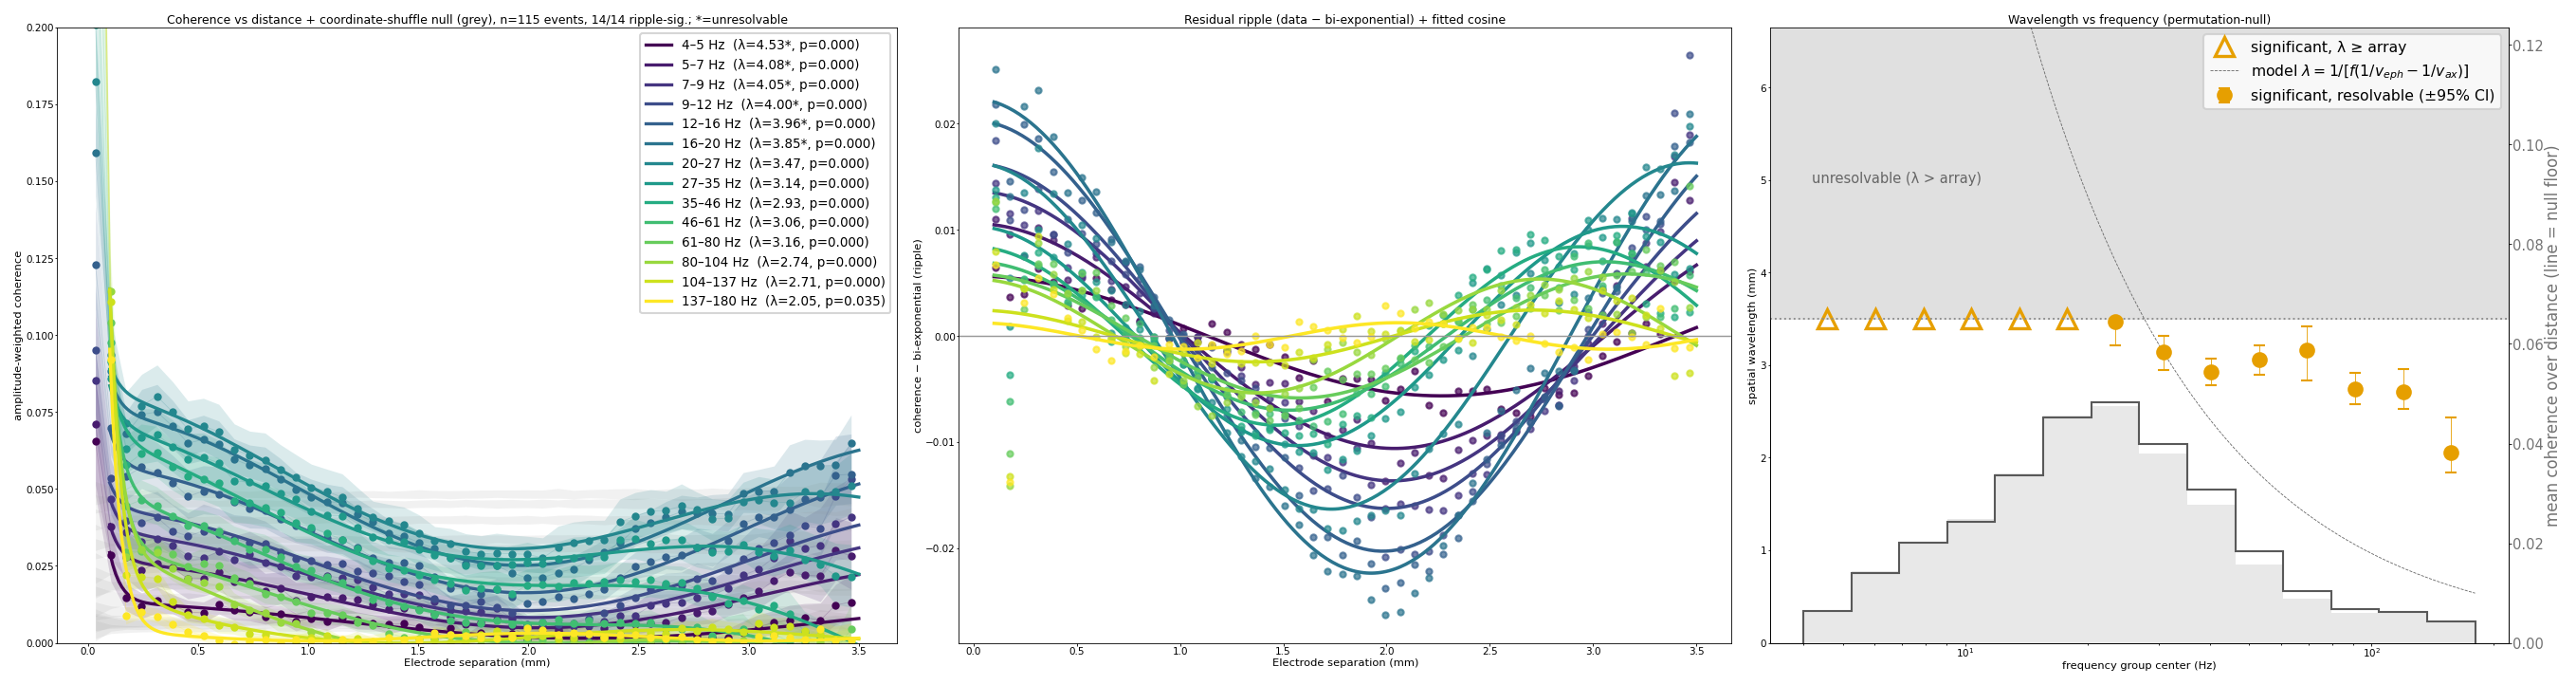

wavelength vs frequency (bi-exp permutation null, p<0.05): 14/14 ripple-significant (8 resolvable, 6 unresolvable); v_eph=0.084 mm/ms


In [127]:
# --- Wavelength vs frequency: ripple significance via a bi-exponential-baseline residual-permutation null ---
# Per-event amplitude-weighted distance maps (cohdist_maps) pooled into wider log-spaced frequency groups.
# SIGNIFICANCE targets the OSCILLATION, not general distance structure. The monotone decay is modelled by a
# BI-exponential baseline (a single exponential is too rigid: bi-exponential decay then leaves a smooth
# residual that a cosine + permutation misreads as a ripple). We fit the bi-exp baseline, permute the
# variance-standardised residuals across distance bins (destroying spatial periodicity while preserving each
# bin's noise magnitude) and refit -- p_ripple is the fraction of permuted curves whose cosine improves the
# fit (dBIC) at least as much as observed. Because a bi-exponential is strictly monotone it cannot fake an
# oscillation, so genuine ripples survive while smooth non-exponential curvature is absorbed and rejected.
# The test is SNR-aware (low-coherence bands cannot pass on noise). The coordinate-shuffle null (grey band)
# is kept only as a separate "coherence above chance" control. Significant groups whose wavelength exceeds
# the array are flagged unresolvable (predicted at low frequency); the resolvable set carries the claim.
# Wavelength CIs for resolvable groups come from an event-level bootstrap.
COHDIST_N_FREQ_GROUPS = 14
COHDIST_WL_CEILING_MM = COHDIST_FIT_MAX_DIST_MM       # max resolvable wavelength ~ the fit range
COHDIST_FG_BOOTSTRAP = COHDIST_BOOTSTRAP_REPS         # event resamples for the wavelength CI only
COHDIST_RIPPLE_PERM_REPS = 200                        # residual-permutation surrogates for the ripple test

_fg_edges = np.geomspace(PHASE_COH_FREQ_LOW_HZ, PHASE_COH_FREQ_HIGH_HZ, COHDIST_N_FREQ_GROUPS + 1)
_fg_centers = np.sqrt(_fg_edges[:-1] * _fg_edges[1:])
_fg_fitbins = (cohdist_centers >= COHDIST_FIT_MIN_DIST_MM) & (cohdist_centers <= COHDIST_FIT_MAX_DIST_MM)
_wl_hi = COHDIST_WL_CEILING_MM * 1.4

def _coh_biexp_model(r, a1, l1, a2, l2, b):
    return a1 * np.exp(-r / l1) + a2 * np.exp(-r / l2) + b            # strictly monotone-decreasing baseline

def _coh_biexpcos_model(r, a1, l1, a2, l2, b, c, wl):
    return _coh_biexp_model(r, a1, l1, a2, l2, b) + c * np.cos(2 * np.pi * r / wl)

_biexp_lo = [0.0, 0.3, 0.0, 0.05, -1.0]; _biexp_hi = [3.0, 20.0, 3.0, 0.6, 1.0]   # l1 slow, l2 fast
_bec_lo = [*_biexp_lo, 0.0, 0.3]; _bec_hi = [*_biexp_hi, 1.0, _wl_hi]

def _fit_group_wl(cr):
    """bi-exp + bi-exp+cos fit of one C(r); returns params, wavelength and the cos-vs-baseline dBIC."""
    m = np.isfinite(cr) & _fg_fitbins
    if m.sum() < 8:
        return None
    r, y, w = cohdist_centers[m], cr[m], np.maximum(cohdist_pair_counts[m], 1e-9); sig = 1.0 / np.sqrt(w)
    amp = max(y.max() - y.min(), 1e-3)
    try:
        pe, _ = curve_fit(_coh_biexp_model, r, y, p0=[amp, 1.5, amp, 0.3, float(np.median(y))],
                          sigma=sig, maxfev=60000, bounds=(_biexp_lo, _biexp_hi))
        pf, _ = curve_fit(_coh_biexpcos_model, r, y, p0=[*pe, .05, min(2.3, _wl_hi)],
                          sigma=sig, maxfev=100000, bounds=(_bec_lo, _bec_hi))
    except Exception:
        return None
    rss_e = float(np.sum(w*(y-_coh_biexp_model(r,*pe))**2)); rss_f = float(np.sum(w*(y-_coh_biexpcos_model(r,*pf))**2))
    return {"p_base": pe, "p_full": pf, "wavelength": float(pf[-1]), "dbic": float(r.size*np.log(rss_f/rss_e) + 2*np.log(r.size))}

def _ripple_perm_fit(cr, reps, seed):
    """Observed bi-exp+cos fit + residual-permutation p-value for the ripple (see cell header)."""
    fit = _fit_group_wl(cr)
    if fit is None:
        return None
    m = np.isfinite(cr) & _fg_fitbins
    r, y, w = cohdist_centers[m], cr[m], np.maximum(cohdist_pair_counts[m], 1e-9); sig = 1.0 / np.sqrt(w)
    pe = fit["p_base"]; obs_dbic = fit["dbic"]
    trend = _coh_biexp_model(r, *pe); z = (y - trend) * np.sqrt(w)       # variance-standardised residual
    rng = np.random.default_rng(seed); nd = np.empty(reps)
    for k in range(reps):
        yk = trend + rng.permutation(z) / np.sqrt(w)
        try:
            pek, _ = curve_fit(_coh_biexp_model, r, yk, p0=list(pe), sigma=sig, maxfev=60000, bounds=(_biexp_lo, _biexp_hi))
            pfk, _ = curve_fit(_coh_biexpcos_model, r, yk, p0=[*pek, .05, min(2.3, _wl_hi)], sigma=sig, maxfev=100000, bounds=(_bec_lo, _bec_hi))
            re = float(np.sum(w*(yk-_coh_biexp_model(r,*pek))**2)); rf = float(np.sum(w*(yk-_coh_biexpcos_model(r,*pfk))**2))
            nd[k] = r.size*np.log(rf/re) + 2*np.log(r.size)
        except Exception:
            nd[k] = np.nan
    fit["p_ripple"] = float(np.nanmean(nd <= obs_dbic)) if np.isfinite(obs_dbic) else 1.0
    return fit

_fg_rng = np.random.default_rng(COHDIST_SEED)
_n_ev = cohdist_maps.shape[0]

# pool per-event maps into frequency groups (cheap); the coordinate-shuffle null (cohdist_null_agg)
# supplies the grey "coherence above chance" band only -- significance uses the permutation null below.
_gmeta = []
for gi in range(COHDIST_N_FREQ_GROUPS):
    lo, hi = _fg_edges[gi], _fg_edges[gi + 1]
    upper = (coh_band_centers <= hi) if gi == COHDIST_N_FREQ_GROUPS - 1 else (coh_band_centers < hi)
    bmask = (coh_band_centers >= lo) & upper
    if not bmask.any():
        continue
    ev_cr = np.nanmean(cohdist_maps[:, bmask, :], axis=1)                 # (n_events, n_bins)
    cr = np.nanmean(ev_cr, axis=0)
    null_cr = np.nanmean(cohdist_null_agg[bmask], axis=0)                 # (reps, n_bins)
    boot_cr = np.array([np.nanmean(ev_cr[_fg_rng.integers(0, _n_ev, _n_ev)], axis=0) for _ in range(COHDIST_FG_BOOTSTRAP)])
    cilo, cihi = np.nanpercentile(boot_cr, [2.5, 97.5], axis=0)
    null_lo, null_hi = np.nanpercentile(null_cr, [2.5, 97.5], axis=0)
    _gmeta.append({"gi": gi, "lo": lo, "hi": hi, "center": _fg_centers[gi], "cr": cr, "ev_cr": ev_cr,
                   "cilo": cilo, "cihi": cihi, "null_lo": null_lo, "null_hi": null_hi,
                   "null_level": float(np.nanmean(null_cr)), "coh_level": float(np.nanmean(cr[_fg_fitbins]))})

# the residual-permutation ripple test (per-group reps fits) dominates -> parallelize across groups
try:
    _gfits = Parallel(n_jobs=-1)(delayed(_ripple_perm_fit)(g["cr"], COHDIST_RIPPLE_PERM_REPS, COHDIST_SEED + g["gi"]) for g in _gmeta)
except Exception as _exc:
    print(f"parallel ripple null unavailable ({_exc}); serial")
    _gfits = [_ripple_perm_fit(g["cr"], COHDIST_RIPPLE_PERM_REPS, COHDIST_SEED + g["gi"]) for g in _gmeta]

_fg = []
for g, fit in zip(_gmeta, _gfits):
    p_ripple = fit["p_ripple"] if fit else 1.0
    significant = bool(fit is not None and p_ripple < COHDIST_NULL_ALPHA)
    wl = fit["wavelength"] if fit else np.nan
    g.update({"fit": fit, "obs_dbic": (fit["dbic"] if fit else np.nan), "p_ripple": p_ripple, "significant": significant,
              "resolvable": bool(significant and np.isfinite(wl) and wl < COHDIST_WL_CEILING_MM),
              "unresolvable": bool(significant and np.isfinite(wl) and wl >= COHDIST_WL_CEILING_MM),
              "wl_ci": (np.nan, np.nan)})
    _fg.append(g)

# event-bootstrap wavelength CI for resolvable groups only
for g in _fg:
    if not g["resolvable"]:
        continue
    bwl = np.full(COHDIST_FG_BOOTSTRAP, np.nan)
    for bi in range(COHDIST_FG_BOOTSTRAP):
        fb = _fit_group_wl(np.nanmean(g["ev_cr"][_fg_rng.integers(0, _n_ev, _n_ev)], axis=0))
        if fb and fb["wavelength"] < COHDIST_WL_CEILING_MM:
            bwl[bi] = fb["wavelength"]
    if np.isfinite(bwl).sum() >= 10:
        g["wl_ci"] = tuple(np.nanpercentile(bwl, [2.5, 97.5]))

_sig = [g for g in _fg if g["significant"]]
_res = [g for g in _fg if g["resolvable"]]
_unr = [g for g in _fg if g["unresolvable"]]
_cmap = plt.cm.viridis
def _col(g): return _cmap(g["gi"] / max(COHDIST_N_FREQ_GROUPS - 1, 1))
_rr = np.linspace(COHDIST_FIT_MIN_DIST_MM, COHDIST_FIT_MAX_DIST_MM, 250)

fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(18, 4.7), constrained_layout=True, gridspec_kw={"width_ratios": [1.25, 1.15, 1.1]})

for g in _fg:                                                    # faint context
    axA.plot(cohdist_centers, g["cr"], "-", lw=0.4, color=_col(g), alpha=0.2)
for g in _sig:                                                  # C(r) + CI + null band + fit
    axA.fill_between(cohdist_centers, g["null_lo"], g["null_hi"], color="0.6", alpha=0.13, lw=0)   # coordinate-shuffle null
    axA.fill_between(cohdist_centers, g["cilo"], g["cihi"], color=_col(g), alpha=0.16, lw=0)
    axA.plot(cohdist_centers, g["cr"], "o", color=_col(g), ms=3)
    axA.plot(_rr, _coh_biexpcos_model(_rr, *g["fit"]["p_full"]), "-", color=_col(g), lw=1.6,
             label=f"{g['lo']:.0f}–{g['hi']:.0f} Hz  (λ={g['fit']['wavelength']:.2f}{'*' if g['unresolvable'] else ''}, p={g['p_ripple']:.3f})")
axA.axhline(0, color="0.7", lw=0.6)
axA.set(xlabel="Electrode separation (mm)", ylabel="amplitude-weighted coherence",
        title=f"Coherence vs distance + coordinate-shuffle null (grey), n={_n_ev} events, {len(_sig)}/{len(_fg)} ripple-sig.; *=unresolvable", ylim=(0, 0.2))
if _sig:
    axA.legend(fontsize=6.5, ncol=1)

for g in _sig:                                                  # bi-exp baseline residual -> isolated ripple
    a1, l1, a2, l2, b, c, wl = g["fit"]["p_full"]
    resid = g["cr"] - _coh_biexp_model(cohdist_centers, a1, l1, a2, l2, b)
    axB.plot(cohdist_centers[_fg_fitbins], resid[_fg_fitbins], "o", color=_col(g), ms=3, alpha=0.7)
    axB.plot(_rr, c * np.cos(2 * np.pi * _rr / wl), "-", color=_col(g), lw=1.7)
axB.axhline(0, color="0.6", lw=0.7)
axB.set(xlabel="Electrode separation (mm)", ylabel="coherence − bi-exponential (ripple)",
        title="Residual ripple (data − bi-exponential) + fitted cosine")

if _res:
    _yerr = np.abs(np.array([[g["fit"]["wavelength"] - g["wl_ci"][0] for g in _res],
                             [g["wl_ci"][1] - g["fit"]["wavelength"] for g in _res]]))
    axC.errorbar([g["center"] for g in _res], [g["fit"]["wavelength"] for g in _res], yerr=_yerr,
                 fmt="o", color=FIGURE3_ACCENT_COLOR, ms=7, capsize=3, label="significant, resolvable (±95% CI)")
if _unr:
    axC.plot([g["center"] for g in _unr], [COHDIST_WL_CEILING_MM] * len(_unr), "^",
             color=FIGURE3_ACCENT_COLOR, mfc="none", mew=1.6, ms=10, label="significant, λ ≥ array")
axC.axhspan(COHDIST_WL_CEILING_MM, COHDIST_WL_CEILING_MM * 1.9, color="0.88", zorder=0)
axC.axhline(COHDIST_WL_CEILING_MM, color="0.55", lw=0.9, ls=":")
axC.text(_fg_edges[0] * 1.05, COHDIST_WL_CEILING_MM * 1.42, "unresolvable (λ > array)", fontsize=7, color="0.4")
try:
    _veph = float(speed_panel_hierarchical_summary["median_mm_per_s"]); _vax = COHDIST_MODEL_VAX_MM_PER_MS * 1000.0
    _ff = np.geomspace(_fg_edges[0], _fg_edges[-1], 200)
    axC.plot(_ff, 1.0 / (_ff * (1.0 / _veph - 1.0 / _vax)), "--", color="0.4",
             label=r"model $\lambda=1/[f(1/v_{eph}-1/v_{ax})]$")
except Exception:
    pass
_coh_level = np.full(COHDIST_N_FREQ_GROUPS, np.nan); _null_floor = np.full(COHDIST_N_FREQ_GROUPS, np.nan)
for g in _fg:
    _coh_level[g["gi"]] = g["coh_level"]; _null_floor[g["gi"]] = g["null_level"]
axCb = axC.twinx()
axCb.set_zorder(axC.get_zorder() - 1); axC.patch.set_visible(False)
axCb.stairs(np.nan_to_num(_coh_level), _fg_edges, fill=True, color="0.45", alpha=0.16, baseline=0.0)
axCb.stairs(np.nan_to_num(_null_floor), _fg_edges, color="0.35", lw=1.0, baseline=0.0)   # null coherence floor
axCb.set_ylim(0, np.nanmax(_coh_level) * 2.6 if np.any(np.isfinite(_coh_level)) else 1.0)
axCb.set_ylabel("mean coherence over distance (line = null floor)", color="0.45", fontsize=8)
axCb.tick_params(axis="y", labelcolor="0.45", labelsize=7)
axC.set(xlabel="frequency group center (Hz)", ylabel="spatial wavelength (mm)", title="Wavelength vs frequency (permutation-null)",
        xscale="log", ylim=(0, COHDIST_WL_CEILING_MM * 1.9))
axC.legend(fontsize=7.5, loc="upper right")

fg_wavelength_df = pd.DataFrame([{"freq_lo_hz": g["lo"], "freq_hi_hz": g["hi"], "freq_center_hz": g["center"],
    "coherence_level": g["coh_level"], "null_level": g["null_level"], "wavelength_mm": (g["fit"]["wavelength"] if g["fit"] else np.nan),
    "wl_ci_low_mm": g["wl_ci"][0], "wl_ci_high_mm": g["wl_ci"][1],
    "dbic": g["obs_dbic"], "p_ripple": g["p_ripple"], "significant": g["significant"],
    "resolvable": g["resolvable"], "unresolvable": g["unresolvable"]} for g in _fg])
fg_wavelength_df.to_csv(OUTPUT_DIR / "wavelength_by_frequency_group.csv", index=False)
fig.savefig(OUTPUT_DIR / "wavelength_vs_frequency.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"wavelength vs frequency (bi-exp permutation null, p<{COHDIST_NULL_ALPHA}): {len(_sig)}/{len(_fg)} ripple-significant "
      f"({len(_res)} resolvable, {len(_unr)} unresolvable); v_eph={speed_panel_hierarchical_summary['median_mm_per_s']/1000.0:.3f} mm/ms")


### Coherence vs distance by burst-peak activity quartile

The same aggregate as above, but with events split into quartiles by spiking activity near the burst
anchor (spike count in `[anchor - 25 ms, anchor + 40 ms]`, the same metric used to rank events for the
phase GIFs). This **reuses the cached per-event maps** (`cohdist_maps`) — no coherence is recomputed;
only the per-event spike counts are loaded. Lets us see whether the low-gamma cosine structure and its
wavelength depend on how strongly the network is bursting.

events per quartile: [29, 29, 29, 28] | activity range: (264.0, 1175.0)


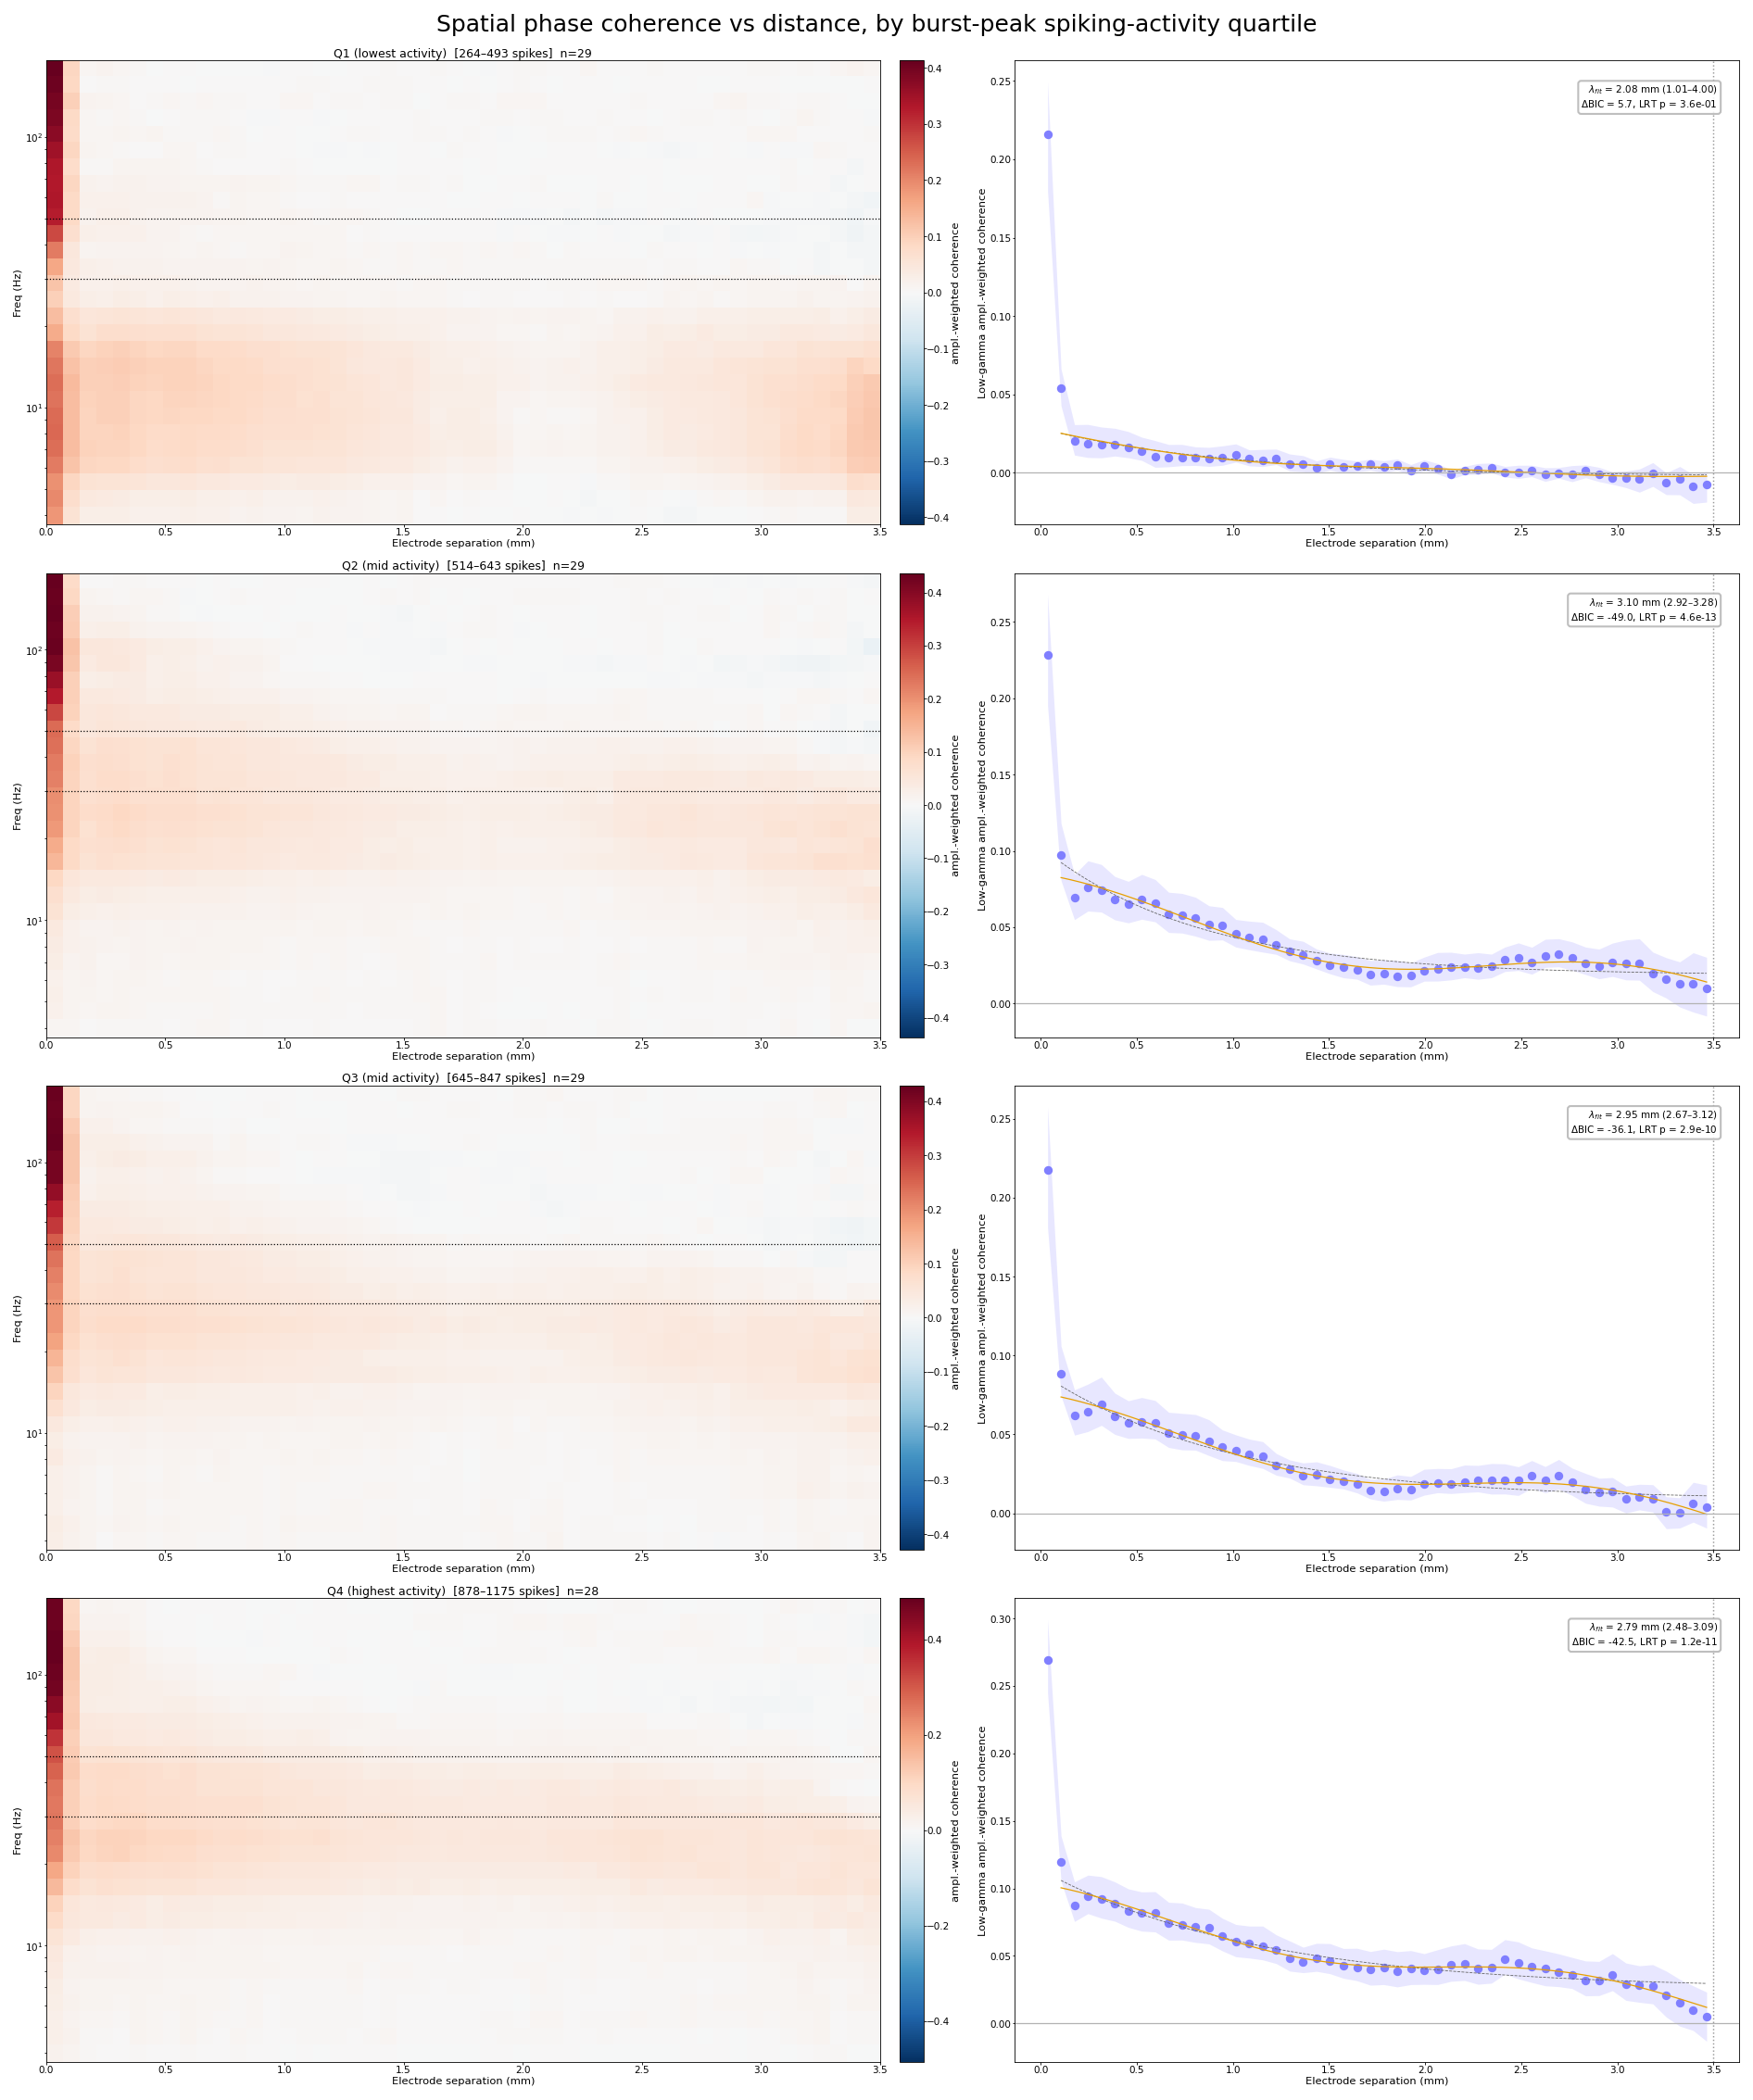

In [125]:
# --- Coherence vs distance split by burst-peak spiking-activity quartile ---
# Rank events by spike count near the anchor (same metric as the GIF selection), split into
# quartiles, and reuse the CACHED per-event maps (cohdist_maps) -- no coherence recomputation.
from ephax.metrics.lfp import load_data_store_spikes, dataset_for_well

QUARTILE_PRE_MS = float(globals().get("LFP_EVENT_GIF_PRE_MS", 25.0))
QUARTILE_POST_MS = float(globals().get("LFP_EVENT_GIF_POST_MS", 40.0))

_anchor_lookup = {
    (int(w), int(e)): float(a)
    for w, e, a in event_df[["well", "event_idx", "anchor_time_s"]].dropna().itertuples(index=False, name=None)
}
_spikes_by_well = {}
for _w in sorted({int(w) for w, _ in cohdist_meta}):
    _sp, _, _ = load_data_store_spikes(STIM_REMOVAL_NULL_LFP_FILE, dataset_for_well(_w), min_amp=MIN_AMP)
    _spikes_by_well[_w] = np.asarray(_sp["time"], dtype=float)

_pre_s, _post_s = QUARTILE_PRE_MS / 1000.0, QUARTILE_POST_MS / 1000.0
event_activity = np.full(len(cohdist_meta), np.nan)
for i, (w, e) in enumerate(cohdist_meta):
    a = _anchor_lookup.get((int(w), int(e)), np.nan)
    if np.isfinite(a):
        st = _spikes_by_well[int(w)]
        event_activity[i] = float(np.count_nonzero((st >= a - _pre_s) & (st <= a + _post_s)))

# equal-count quartiles by rank (robust to ties in spike counts); Q1 lowest -> Q4 highest activity
_order = np.flatnonzero(np.isfinite(event_activity))
_order = _order[np.argsort(event_activity[_order], kind="stable")]
quartile = np.full(len(cohdist_meta), -1, dtype=int)
quartile[_order] = np.floor(np.arange(_order.size) * 4 / max(_order.size, 1)).astype(int)
print("events per quartile:", [int(np.count_nonzero(quartile == q)) for q in range(4)],
      "| activity range:", (float(np.nanmin(event_activity)), float(np.nanmax(event_activity))))


def _fit_lowgamma(maps_sub, rng):
    ev_cr = np.nanmean(maps_sub[:, lowgamma_mask, :], axis=1)          # (n_sub, n_bins)
    pooled = np.nanmean(ev_cr, axis=0)
    fmask = np.isfinite(pooled) & (cohdist_centers <= COHDIST_FIT_MAX_DIST_MM) & (cohdist_centers >= COHDIST_FIT_MIN_DIST_MM)
    r_fit, w_fit = cohdist_centers[fmask], cohdist_pair_counts[fmask]
    n_ev = ev_cr.shape[0]
    boot = np.full((COHDIST_BOOTSTRAP_REPS, cohdist_centers.size), np.nan)
    boot_wl = np.full(COHDIST_BOOTSTRAP_REPS, np.nan)
    for bi in range(COHDIST_BOOTSTRAP_REPS):
        idx = rng.integers(0, n_ev, n_ev)
        yb = np.nanmean(ev_cr[idx], axis=0)
        boot[bi] = yb
        m = np.isfinite(yb) & (cohdist_centers <= COHDIST_FIT_MAX_DIST_MM) & (cohdist_centers >= COHDIST_FIT_MIN_DIST_MM)
        if m.sum() >= 6:
            try:
                _, pf, _, _ = _fit_coh_models(cohdist_centers[m], yb[m], cohdist_pair_counts[m])
                boot_wl[bi] = pf[4]
            except Exception:
                pass
    ci_lo, ci_hi = np.nanpercentile(boot, [2.5, 97.5], axis=0)
    p_exp, p_full, rss_exp, rss_full = _fit_coh_models(r_fit, pooled[fmask], w_fit)
    n_fit = r_fit.size
    chi2 = n_fit * np.log(rss_exp / rss_full)
    return {
        "pooled": pooled, "ci_lo": ci_lo, "ci_hi": ci_hi, "p_exp": p_exp, "p_full": p_full,
        "r_fit": r_fit, "wavelength": float(p_full[4]),
        "wl_ci": tuple(np.nanpercentile(boot_wl, [2.5, 97.5])),
        "dbic": n_fit * np.log(rss_full / rss_exp) + 2.0 * np.log(n_fit),
        "lrt_p": float(_chi2_dist.sf(chi2, 2)), "rss_red": 100.0 * (1.0 - rss_full / rss_exp),
    }


def _draw_quartile_row(maps_sub, ax_h, ax_l, title, rng):
    agg = np.ma.masked_invalid(np.nanmean(maps_sub, axis=0))
    vmax = max(float(np.abs(agg).max()) if agg.count() else 1.0, np.finfo(float).eps)
    mesh = ax_h.pcolormesh(cohdist_centers, coh_band_centers, agg, shading="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    for edge in (COHDIST_LOWGAMMA_HZ[0], COHDIST_LOWGAMMA_HZ[1]):
        ax_h.axhline(edge, color="k", lw=0.6, ls=":")
    ax_h.set_yscale("log")
    ax_h.set(xlabel="Electrode separation (mm)", ylabel="Freq (Hz)", title=title)
    ax_h.figure.colorbar(mesh, ax=ax_h, pad=0.015).set_label("ampl.-weighted coherence")

    f = _fit_lowgamma(maps_sub, rng)
    ax_l.fill_between(cohdist_centers, f["ci_lo"], f["ci_hi"], color=FIGURE3_PRIMARY_COLOR, alpha=0.18, linewidth=0)
    ax_l.plot(cohdist_centers, f["pooled"], "o", color=FIGURE3_PRIMARY_COLOR, ms=3.5)
    r_dense = np.linspace(f["r_fit"].min(), f["r_fit"].max(), 200)
    ax_l.plot(r_dense, _coh_exp_model(r_dense, *f["p_exp"]), ls="--", color="0.4", lw=LINE_WIDTHS["base"])
    ax_l.plot(r_dense, _coh_expcos_model(r_dense, *f["p_full"]), ls="-", color=FIGURE3_ACCENT_COLOR, lw=LINE_WIDTHS["emphasis"])
    ax_l.axvline(COHDIST_FIT_MAX_DIST_MM, color="0.6", lw=0.7, ls=":")
    ax_l.axhline(0.0, color="0.7", lw=0.6)
    ax_l.text(0.97, 0.95,
              f"$\\lambda_{{fit}}$ = {f['wavelength']:.2f} mm ({f['wl_ci'][0]:.2f}–{f['wl_ci'][1]:.2f})\n"
              f"$\\Delta$BIC = {f['dbic']:.1f}, LRT p = {f['lrt_p']:.1e}",
              transform=ax_l.transAxes, ha="right", va="top", fontsize=FONT_SIZES.get("small", 8),
              bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.85))
    ax_l.set(xlabel="Electrode separation (mm)", ylabel="Low-gamma ampl.-weighted coherence")


_qrng = np.random.default_rng(COHDIST_SEED)
fig, axes = plt.subplots(4, 2, figsize=(12.5, 15.0), constrained_layout=True,
                         gridspec_kw={"width_ratios": [1.15, 1.0]})
for q in range(4):
    sel = np.flatnonzero(quartile == q)
    if sel.size < 3:
        for ax in axes[q]:
            ax.set_title(f"Q{q+1}: too few events (n={sel.size})"); ax.axis("off")
        continue
    amin, amax = event_activity[sel].min(), event_activity[sel].max()
    title = f"Q{q+1} ({'lowest' if q==0 else 'highest' if q==3 else 'mid'} activity)  [{amin:.0f}–{amax:.0f} spikes]  n={sel.size}"
    _draw_quartile_row(cohdist_maps[sel], axes[q, 0], axes[q, 1], title, _qrng)
fig.suptitle("Spatial phase coherence vs distance, by burst-peak spiking-activity quartile", fontsize=FONT_SIZES.get("large", 12))
plt.show()